# Основной ноутбук экспериментов TabBERT

Этот ноутбук является главным исследовательским ноутбуком по ВКР и объединяет базовую иерархическую модель и несколько абляций.

Что важно учитывать при чтении:
- здесь же проводились эксперименты с длиной окна истории `5`, `10` и `15`;
- в сохраненных output сейчас остался только вывод последнего запуска, поэтому часть промежуточных результатов не видна как отдельные блоки вывода;
- внутри ноутбука есть исследовательские и черновые секции, поэтому его стоит читать как рабочий источник экспериментов, а не как полностью очищенный финальный артефакт.

Основная роль ноутбука в структуре репозитория: базовая модель, ключевые абляции и проверка гипотез из дипломной работы.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertConfig, BertModel
from collections import Counter
import json
import os
from tqdm import tqdm
import random
import pickle

class TabBertVocabBuilder:
    """Класс для создания словаря признаков транзакций и границ бинов"""

    def __init__(self, df, categorical_columns, numerical_columns, special_tokens=None):
        """
        Args:
            df: DataFrame с транзакциями
            categorical_columns: список категориальных колонок
            numerical_columns: список числовых колонок
            special_tokens: специальные токены
        """
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns

        if special_tokens is None:
            self.special_tokens = ['[PAD]', '[CLS]', '[SEP]', '[MASK]', '[UNK]']
        else:
            self.special_tokens = special_tokens

        # Сохраняем границы бинов для каждой числовой колонки
        self.bin_edges = {}

        self.vocab = self._build_vocab(df)

    def _build_vocab(self, df):
        """Создание словаря из уникальных значений и границ бинов"""
        vocab_dict = {}

        # Добавляем специальные токены
        for i, token in enumerate(self.special_tokens):
            vocab_dict[token] = i

        current_idx = len(self.special_tokens)

        # Добавляем токены для категориальных колонок
        for col in self.categorical_columns:
            unique_values = df[col].astype(str).unique()
            for val in unique_values:
                token = f"{col}_{val}"
                if token not in vocab_dict:
                    vocab_dict[token] = current_idx
                    current_idx += 1
        return vocab_dict



    def save(self, path):
        """Сохранить словарь и границы бинов"""
        save_dict = {
            'vocab': self.vocab,
            'bin_edges': self.bin_edges,
            'categorical_columns': self.categorical_columns,
            'numerical_columns': self.numerical_columns,
            'special_tokens': self.special_tokens,
        }

        with open(path, 'wb') as f:
            pickle.dump(save_dict, f)
        print(f"TabBertVocab saved to {path}")

    @classmethod
    def load(cls, path):
        """Загрузить словарь и границы бинов"""
        with open(path, 'rb') as f:
            save_dict = pickle.load(f)

        # Создаем экземпляр без вычислений
        instance = cls.__new__(cls)
        instance.vocab = save_dict['vocab']
        instance.bin_edges = save_dict['bin_edges']
        instance.categorical_columns = save_dict['categorical_columns']
        instance.numerical_columns = save_dict['numerical_columns']
        instance.special_tokens = save_dict['special_tokens']

        print(f"TabBertVocab loaded from {path}. Size: {len(instance.vocab)}")
        return instance




2026-05-03 14:55:19.969380: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777809319.997145  105117 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777809320.005884  105117 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777809320.028481  105117 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777809320.028532  105117 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777809320.028535  105117 computation_placer.cc:177] computation placer alr

In [ ]:

class TabBertTokenizer:
    """Токенизатор для табличных данных с поддержкой бинов"""

    def __init__(self, vocab_builder, max_length=128):
        """
        Args:
            vocab_builder: экземпляр TabBertVocabBuilder с сохраненными бинами
            max_length: максимальная длина последовательности
        """
        self.vocab_builder = vocab_builder
        self.vocab = vocab_builder.vocab
        self.max_length = max_length
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def tokenize_transaction(self, transaction_row, categorical_columns=None, numerical_columns=None):
        """
        Токенизация одной транзакции с использованием бинов для числовых значений

        Args:
            transaction_row: строка DataFrame с транзакцией
            categorical_columns: список категориальных колонок (если None, используются из vocab_builder)
            numerical_columns: список числовых колонок (если None, используются из vocab_builder)

        Returns:
            список токенов
        """
        if categorical_columns is None:
            categorical_columns = self.vocab_builder.categorical_columns
        if numerical_columns is None:
            numerical_columns = self.vocab_builder.numerical_columns

        tokens = ['[CLS]']  # Начинаем с CLS токена

        # Добавляем категориальные признаки
        for col in categorical_columns:
            if col in transaction_row.index:
                val = str(transaction_row[col]) if not pd.isna(transaction_row[col]) else 'missing'
                token = f"{col}_{val}"
                if token not in self.vocab:
                    token = '[UNK]'
                tokens.append(token)
            else:
                tokens.append('[UNK]')

        # Добавляем числовые признаки с использованием бинов
        for col in numerical_columns:
            if col in transaction_row.index:
                val = float(transaction_row[col])
                token = f"{col}_{val}"
            else:
                token = f"{col}_missing"

            tokens.append(token)

        tokens.append('[SEP]')
        return tokens

    def convert_tokens_to_ids(self, tokens):
        """Конвертация токенов в индексы"""
        ids = []
        for token in tokens:
            if token.split('_')[0] in self.vocab_builder.numerical_columns:
                ids.append(token)
            else:
                ids.append(self.vocab.get(token, self.vocab['[UNK]']))
        return ids

    def convert_ids_to_tokens(self, ids):
        """Конвертация индексов в токены"""
        tokens = []
        
        for id_one in ids:
            if str(id_one).split('_')[0] in self.vocab_builder.numerical_columns:
                tokens.append(id_one)
            else:
                tokens.append(self.inv_vocab.get(id_one, self.vocab['[UNK]']))
        return tokens


In [ ]:
import pandas as pd

df = pd.read_csv('card_transaction.v1.prepare.csv')

In [5]:
# categorical_columns = ['user_id', 'Card', 'Year', 'Month' , 'Day', 'hour', 'minute',  'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'is_refund']
categorical_columns = ['user', 'Card',  'Month' , 'Day', 'hour', 'minute',  'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'isrefund']
numerical_columns = ['Amount']


# vocab_builder = TabBertVocabBuilder(df, categorical_columns, numerical_columns)
# vocab_builder.save('tabbert_v7/tabbert_vocab_all.pkl')



vocab_builder = TabBertVocabBuilder.load('tabbert_v7/tabbert_vocab_all.pkl')

tokenizer = TabBertTokenizer(vocab_builder, max_length=32)





TabBertVocab loaded from tabbert_v7/tabbert_vocab_all.pkl. Size: 143597


In [6]:
class TabBertTokenizer:
    """Токенизатор для табличных данных"""

    def __init__(self, vocab_builder, max_length=10):
        """
        Args:
            vocab_builder: экземпляр TabBertVocabBuilder
            max_length: максимальная длина последовательности
        """
        self.vocab_builder = vocab_builder
        self.vocab = vocab_builder.vocab
        self.max_length = max_length
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def tokenize_transaction(self, transaction_row, categorical_columns=None, numerical_columns=None):
        """
        Токенизация одной транзакции
        
        Returns:
            tuple: (categorical_ids, numerical_values, tokens) - 3 значения
        """
        if categorical_columns is None:
            categorical_columns = self.vocab_builder.categorical_columns
        if numerical_columns is None:
            numerical_columns = self.vocab_builder.numerical_columns

        tokens = ['[CLS]']  # Начинаем с CLS токена
        categorical_ids = [self.vocab.get('[CLS]')]
        numerical_values = []

        # Добавляем категориальные признаки
        for col in categorical_columns:
            if col in transaction_row.index:
                val = str(transaction_row[col]) if not pd.isna(transaction_row[col]) else 'missing'
                token = f"{col}_{val}"
                token_id = self.vocab.get(token, self.vocab['[UNK]'])
                tokens.append(token)
                categorical_ids.append(token_id)
            else:
                tokens.append('[UNK]')
                categorical_ids.append(self.vocab['[UNK]'])

        # Добавляем числовые признаки (исходные значения)
        for col in numerical_columns:
            if col in transaction_row.index and not pd.isna(transaction_row[col]):
                val = float(transaction_row[col])
                numerical_values.append(val)
                tokens.append(f"{col}_{val:.2f}")  # Для отладки
            else:
                numerical_values.append(0.0)  # Значение по умолчанию для пропущенных
                tokens.append(f"{col}_missing")

        tokens.append('[SEP]')
        categorical_ids.append(self.vocab.get('[SEP]'))
        
        # Обрезаем до max_length если нужно
        if len(tokens) > self.max_length:
            tokens = tokens[:self.max_length]
            categorical_ids = categorical_ids[:self.max_length - 1]
            numerical_values = numerical_values[:self.max_length - 1]
        
        # Добавляем PAD до max_length
        current_len = len(tokens)
        if current_len < self.max_length:
            padding_len = self.max_length - current_len
            tokens += ['[PAD]'] * padding_len
            categorical_ids += [self.vocab['[PAD]']] * padding_len
            numerical_values += [0.0] * padding_len
        
        # Возвращаем 3 значения: categorical_ids, numerical_values, tokens
        return categorical_ids, numerical_values, tokens

    def convert_tokens_to_ids(self, tokens):
        """Конвертация токенов в индексы"""
        ids = []
        for token in tokens:
            ids.append(self.vocab.get(token, self.vocab['[UNK]']))
        return ids

    def convert_ids_to_tokens(self, ids):
        """Конвертация индексов в токены"""
        tokens = []
        for id_one in ids:
            tokens.append(self.inv_vocab.get(id_one, '[UNK]'))
        return tokens

In [7]:
tokenizer = TabBertTokenizer(vocab_builder, max_length=17)


In [9]:
class TabBertMLMDataset(Dataset):
    """Более быстрый Dataset: меньше pandas/Python overhead внутри __getitem__."""

    def __init__(self, df, tokenizer, categorical_columns, numerical_columns,
                 max_seq_length=128, history_size=10, stride=None, mask_prob=0.15):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns
        self.max_seq_length = max_seq_length
        self.history_size = history_size
        self.stride = stride if stride is not None else history_size
        self.mask_prob = mask_prob

        self.cls_id = self.tokenizer.vocab['[CLS]']
        self.sep_id = self.tokenizer.vocab['[SEP]']
        self.pad_id = self.tokenizer.vocab['[PAD]']
        self.unk_id = self.tokenizer.vocab['[UNK]']
        self.mask_id = self.tokenizer.vocab['[MASK]']
        self.vocab_size = len(self.tokenizer.vocab)
        self.num_numerical_features = len(self.numerical_columns)
        self.special_ids = {self.cls_id, self.sep_id, self.pad_id}

        # Храним прямые ссылки на колонки DataFrame, чтобы не создавать Series через iloc на каждом sample.
        used_columns = list(dict.fromkeys(self.categorical_columns + self.numerical_columns))
        self.column_arrays = {
            col: self.df[col].to_numpy(copy=False) for col in used_columns
        }

        self.pad_cat_ids = np.full(self.max_seq_length, self.pad_id, dtype=np.int64)
        self.pad_num_values = np.zeros(self.num_numerical_features, dtype=np.float32)
        self.pad_mask = np.zeros(self.max_seq_length, dtype=np.int64)

        # Подготавливаем быстрые словари value -> token_id для категориальных колонок.
        self.cat_value_to_id = {col: {} for col in self.categorical_columns}
        for token, token_id in self.tokenizer.vocab.items():
            if token.startswith('['):
                continue
            col_name, sep, value = token.partition('_')
            if sep and col_name in self.cat_value_to_id:
                self.cat_value_to_id[col_name][value] = token_id

        # Храним окна в компактных массивах вместо списка словарей.
        history_windows = []
        current_indices = []
        client_transactions = self.df.groupby('user').indices

        for indices in client_transactions.values():
            indices = sorted(indices)
            if not indices:
                continue

            if len(indices) <= history_size:
                history_indices = indices[:-1]
                padded_history = [-1] * (history_size - len(history_indices)) + history_indices
                history_windows.append(padded_history)
                current_indices.append(indices[-1])
            else:
                for i in range(history_size, len(indices), self.stride):
                    history_windows.append(indices[i-history_size:i])
                    current_indices.append(indices[i])

        self.history_indices = np.asarray(history_windows, dtype=np.int64)
        self.current_indices = np.asarray(current_indices, dtype=np.int64)

        print(f"Создано {len(self.current_indices)} окон из {len(df)} транзакций")

    def __len__(self):
        return len(self.current_indices)

    def _tokenize_transaction(self, idx):
        """Быстрая токенизация без pandas.iloc внутри training loop."""
        if idx is None or idx < 0:
            return self.pad_cat_ids.copy(), self.pad_num_values.copy(), self.pad_mask.copy()

        cat_ids = self.pad_cat_ids.copy()
        num_values = self.pad_num_values.copy()
        mask = self.pad_mask.copy()

        write_pos = 0
        cat_ids[write_pos] = self.cls_id
        write_pos += 1

        for col in self.categorical_columns:
            if write_pos >= self.max_seq_length - 1:
                break

            value = self.column_arrays[col][idx]
            if pd.isna(value):
                token_id = self.unk_id
            else:
                token_id = self.cat_value_to_id[col].get(str(value), self.unk_id)

            cat_ids[write_pos] = token_id
            write_pos += 1

        if write_pos < self.max_seq_length:
            cat_ids[write_pos] = self.sep_id
            write_pos += 1

        mask[:write_pos] = 1

        for num_idx, col in enumerate(self.numerical_columns):
            value = self.column_arrays[col][idx]
            num_values[num_idx] = 0.0 if pd.isna(value) else float(value)

        return cat_ids, num_values, mask

    def _apply_masking(self, cat_ids, num_values):
        """Размечаем labels только для реально выбранных categorical MLM-позиций."""
        masked_cat_ids = cat_ids.copy()
        cat_labels = np.full_like(cat_ids, fill_value=-100)
        masked_num_values = num_values.copy()
        # Числовую ветку пока оставляем в прежней постановке, чтобы не ломать существующий objective.
        num_labels = num_values.copy().astype(np.float32)

        for i, token_id in enumerate(cat_ids):
            # Специальные токены и UNK не должны участвовать в field-wise MLM loss.
            if token_id in self.special_ids or token_id == self.unk_id:
                continue

            if random.random() < self.mask_prob:
                cat_labels[i] = token_id

                r = random.random()
                if r < 0.8:
                    masked_cat_ids[i] = self.mask_id
                elif r < 0.9:
                    masked_cat_ids[i] = random.randint(0, self.vocab_size - 1)
                # 10% оставляем исходный токен, но loss все равно считаем на этой позиции.

        return masked_cat_ids, cat_labels, masked_num_values, num_labels

    def __getitem__(self, idx):
        current_idx = int(self.current_indices[idx])
        history_indices = self.history_indices[idx]

        history_cat_ids = np.empty((self.history_size, self.max_seq_length), dtype=np.int64)
        history_num_values = np.empty((self.history_size, self.num_numerical_features), dtype=np.float32)
        history_masks = np.empty((self.history_size, self.max_seq_length), dtype=np.int64)
        history_cat_labels = np.empty((self.history_size, self.max_seq_length), dtype=np.int64)
        history_num_labels = np.empty((self.history_size, self.num_numerical_features), dtype=np.float32)

        for pos, hist_idx in enumerate(history_indices):
            cat_ids, num_values, mask = self._tokenize_transaction(int(hist_idx))
            masked_cat_ids, cat_labels, masked_num_values, num_labels = self._apply_masking(cat_ids, num_values)

            history_cat_ids[pos] = masked_cat_ids
            history_num_values[pos] = masked_num_values
            history_masks[pos] = mask
            history_cat_labels[pos] = cat_labels
            history_num_labels[pos] = num_labels

        current_cat_ids, current_num_values, current_mask = self._tokenize_transaction(current_idx)
        masked_current_cat_ids, current_cat_labels, masked_current_num_values, current_num_labels = \
            self._apply_masking(current_cat_ids, current_num_values)

        return {
            'current_cat_ids': torch.from_numpy(masked_current_cat_ids.copy()).long(),
            'current_num_values': torch.from_numpy(masked_current_num_values.copy()).float(),
            'current_mask': torch.from_numpy(current_mask.copy()).long(),
            'current_cat_labels': torch.from_numpy(current_cat_labels.copy()).long(),
            'current_num_labels': torch.from_numpy(current_num_labels.copy()).float(),
            'history_cat_ids': torch.from_numpy(history_cat_ids.copy()).long(),
            'history_num_values': torch.from_numpy(history_num_values.copy()).float(),
            'history_mask': torch.from_numpy(history_masks.copy()).long(),
            'history_cat_labels': torch.from_numpy(history_cat_labels.copy()).long(),
            'history_num_labels': torch.from_numpy(history_num_labels.copy()).float()
        }

In [10]:
class TabBertForFraudDetection(nn.Module):
    def __init__(self, vocab_size, field_ranges, inv_vocab, num_numerical_features = 1, 
                 hidden_size=128,
                 num_classes=2, 
                 max_history=10, freeze_first_bert=True, num_hidden_layers=1):
        super().__init__()
        
        # Сохраняем параметры
        self.field_ranges = field_ranges
        self.inv_vocab = inv_vocab
        self.hidden_size = hidden_size
        self.num_numerical_features = num_numerical_features
        
        # Эмбеддинг для категориальных признаков
        self.cat_embedding = nn.Embedding(vocab_size, hidden_size)
        
        # Линейный слой для числовых признаков
        self.num_projection = nn.Linear(num_numerical_features, hidden_size)
        
        self.num_head = nn.Linear(hidden_size, num_numerical_features)
        
        # Конфигурация для первого BERT (обработка одной транзакции)
        config = BertConfig(
            hidden_size=hidden_size,
            num_hidden_layers=3,
            num_attention_heads=4,
            max_position_embeddings=196,
            type_vocab_size=2,
            intermediate_size=hidden_size * 4
        )
        
        self.transaction_bert = BertModel(config)
        
        # Конфигурация для второго BERT (анализ последовательности)
        config_history = BertConfig(
            hidden_size=hidden_size,
            num_hidden_layers=2,
            num_attention_heads=4,
            intermediate_size=hidden_size * 2,
            max_position_embeddings=1024,
            hidden_dropout_prob=0.3,
            attention_probs_dropout_prob=0.3
        )
        
        self.history_bert = BertModel(config_history)
        
        # Классификатор с Dropout и BatchNorm
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size // 2, num_classes)
        )
        
        # MLM голова
        self.mlm_head = nn.Linear(hidden_size, vocab_size)
        
        # Веса для классов
        self.register_buffer('class_weights', torch.tensor([1.0, 5.0]))
        
    

    def encode_transaction(self, cat_ids, num_values, attention_mask):
        """Кодирует транзакцию и возвращает эмбеддинги всех полей."""
        batch_size = cat_ids.shape[0]

        cat_embeds = self.cat_embedding(cat_ids)
        num_embeds = self.num_projection(num_values).unsqueeze(1)

        all_field_embeds = torch.cat([cat_embeds, num_embeds], dim=1)

        field_mask = torch.cat([
            attention_mask,
            torch.ones((batch_size, 1), device=attention_mask.device, dtype=attention_mask.dtype)
        ], dim=1)

        outputs = self.transaction_bert(
            inputs_embeds=all_field_embeds,
            attention_mask=field_mask
        )

        return outputs.last_hidden_state

    def forward_mlm(self, current_cat_ids, current_num_values, current_mask,
                history_cat_ids, history_num_values, history_mask,
                current_cat_labels, current_num_labels,
                history_cat_labels, history_num_labels):
            """Векторизованный MLM forward: один вызов transaction_bert на весь batch истории."""
            batch_size = current_cat_ids.size(0)
            total_transactions = 1 + history_cat_ids.size(1)
            num_cat_fields = current_cat_ids.size(1)
            num_total_fields = num_cat_fields + 1

            all_cat_ids = torch.cat([
                current_cat_ids.unsqueeze(1),
                history_cat_ids
            ], dim=1)
            all_num_values = torch.cat([
                current_num_values.unsqueeze(1),
                history_num_values
            ], dim=1)
            all_masks = torch.cat([
                current_mask.unsqueeze(1),
                history_mask
            ], dim=1)

            all_cat_labels = torch.cat([
                current_cat_labels.unsqueeze(1),
                history_cat_labels
            ], dim=1)
            all_num_labels = torch.cat([
                current_num_labels.unsqueeze(1),
                history_num_labels
            ], dim=1)

            flat_cat_ids = all_cat_ids.reshape(batch_size * total_transactions, -1)
            flat_num_values = all_num_values.reshape(batch_size * total_transactions, -1)
            flat_masks = all_masks.reshape(batch_size * total_transactions, -1)

            # Один большой forward обычно быстрее, чем много маленьких вызовов BERT в Python-цикле.
            flat_field_embeddings = self.encode_transaction(
                flat_cat_ids,
                flat_num_values,
                flat_masks
            )

            all_field_embeddings = flat_field_embeddings.reshape(
                batch_size,
                total_transactions,
                num_total_fields,
                self.hidden_size
            )

            transaction_mask = (all_masks.sum(dim=2) > 0).to(dtype=flat_field_embeddings.dtype)
            transaction_mask_expanded = transaction_mask.unsqueeze(-1).expand(-1, -1, num_total_fields)
            transaction_mask_expanded = transaction_mask_expanded.reshape(
                batch_size,
                total_transactions * num_total_fields
            )

            sequence_output = all_field_embeddings.reshape(
                batch_size,
                total_transactions * num_total_fields,
                self.hidden_size
            )

            outputs = self.history_bert(
                inputs_embeds=sequence_output,
                attention_mask=transaction_mask_expanded
            )

            field_embeddings = outputs.last_hidden_state.reshape(
                batch_size,
                total_transactions,
                num_total_fields,
                self.hidden_size
            )

            cat_embeddings = field_embeddings[:, :, :-1, :]
            num_embeddings = field_embeddings[:, :, -1, :]

            prediction_scores = self.mlm_head(cat_embeddings)
            num_scores = self.num_head(num_embeddings)

            return prediction_scores, num_scores, all_cat_labels, all_num_labels


    def forward(self, cat_ids, num_values, attention_mask, labels=None):
        """Векторизованный inference/classification forward без цикла по seq_len."""
        batch_size, seq_len = cat_ids.shape[:2]
        num_total_fields = cat_ids.size(-1) + 1

        flat_cat_ids = cat_ids.reshape(batch_size * seq_len, -1)
        flat_num_values = num_values.reshape(batch_size * seq_len, -1)
        flat_attention_mask = attention_mask.reshape(batch_size * seq_len, -1)

        flat_transaction_embeds = self.encode_transaction(
            flat_cat_ids,
            flat_num_values,
            flat_attention_mask
        )

        transaction_embeds = flat_transaction_embeds.reshape(
            batch_size,
            seq_len * num_total_fields,
            self.hidden_size
        )
        valid_mask = (attention_mask.sum(dim=2) > 0).float()
        valid_mask = valid_mask.unsqueeze(-1).expand(-1, -1, num_total_fields)
        valid_mask = valid_mask.reshape(batch_size, seq_len * num_total_fields)

        outputs = self.history_bert(
            inputs_embeds=transaction_embeds,
            attention_mask=valid_mask
        )

        sequence_output = outputs.last_hidden_state.reshape(
            batch_size,
            seq_len,
            num_total_fields,
            self.hidden_size
        )[:, :, 0, :]

        logits = self.classifier(sequence_output.reshape(-1, self.hidden_size))
        logits = logits.reshape(batch_size, seq_len, -1)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            active_loss = (labels != -100).view(-1)
            active_logits = logits.view(-1, logits.size(-1))[active_loss]
            active_labels = labels.view(-1)[active_loss]
            loss = loss_fn(active_logits, active_labels)

        return loss, logits

In [12]:
field_ranges = {'user': {'min': 5, 'max': 2004, 'size': 2000},
 'Card': {'min': 2005, 'max': 2013, 'size': 9},
 'Month': {'min': 2014, 'max': 2025, 'size': 12},
 'Day': {'min': 2026, 'max': 2056, 'size': 31},
 'hour': {'min': 2057, 'max': 2080, 'size': 24},
 'minute': {'min': 2081, 'max': 2140, 'size': 60},
 'Use Chip': {'min': 2141, 'max': 2143, 'size': 3},
 'Merchant Name': {'min': 2144, 'max': 102486, 'size': 100343},
 'Merchant City': {'min': 102487, 'max': 115915, 'size': 13429},
 'Merchant State': {'min': 115916, 'max': 116139, 'size': 224},
 'Zip': {'min': 116140, 'max': 143461, 'size': 27322},
 'MCC': {'min': 143462, 'max': 143570, 'size': 109},
 'Errors?': {'min': 143571, 'max': 143594, 'size': 24},
 'isrefund': {'min': 143595, 'max': 143596, 'size': 2}}

inv_vocab = {v: k for k, v in vocab_builder.vocab.items()}

In [ ]:
# mlm_model = TabBertForFraudDetection(len(vocab_builder.vocab), hidden_size=128)

# # При создании тренера явно указываем устройство
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using device: {device}")


# mlm_model = mlm_model.to(device)  # Явный перенос на CUDA


mlm_model = TabBertForFraudDetection(
    len(vocab_builder.vocab),
    field_ranges=field_ranges,
    inv_vocab=inv_vocab,
    max_history = 5,
    hidden_size=128
)

save_path = 'tabbert_v6/tabbert_model_mlm_epoch_4.pth'
checkpoint = torch.load(save_path, map_location='cpu', weights_only = False)
mlm_model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


mlm_model = mlm_model.to(device)  # Явный перенос на CUDA




Using device: cuda


In [25]:
del mlm_model
del optimizer
import gc
gc.collect()
torch.cuda.empty_cache()

In [60]:

# Базовые backend-оптимизации для одного GPU.
if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = device.type == 'cuda'
amp_dtype = torch.bfloat16 if use_amp and torch.cuda.is_bf16_supported() else torch.float16

print(f"Using device: {device}")
if use_amp:
    print(f"AMP enabled with dtype: {amp_dtype}")

# mlm_model = mlm_model.to(device)



Using device: cuda
AMP enabled with dtype: torch.bfloat16


In [62]:
class TabBertFraudDataset(Dataset):
    """Dataset для fine-tuning на fraud detection, совместимый с forward(cat_ids, num_values, attention_mask, labels)."""

    def __init__(self, df, tokenizer, categorical_columns, numerical_columns,
                 user_col='user', time_col='timestamp', label_col='is_fraud',
                 max_seq_length=128, window_size=10, stride=None, min_window_size=2):
        self.df = df.sort_values([user_col, time_col]).reset_index(drop=True)
        self.tokenizer = tokenizer
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns
        self.user_col = user_col
        self.time_col = time_col
        self.label_col = label_col
        self.max_seq_length = max_seq_length
        self.window_size = window_size
        self.stride = stride if stride is not None else window_size
        self.min_window_size = min_window_size

        self.cls_id = self.tokenizer.vocab['[CLS]']
        self.sep_id = self.tokenizer.vocab['[SEP]']
        self.pad_id = self.tokenizer.vocab['[PAD]']
        self.unk_id = self.tokenizer.vocab['[UNK]']
        self.num_numerical_features = len(self.numerical_columns)

        # Используем массивы колонок, чтобы не дергать pandas.iloc на каждом __getitem__.
        used_columns = list(dict.fromkeys(
            [self.user_col, self.time_col, self.label_col] + self.categorical_columns + self.numerical_columns
        ))
        self.column_arrays = {
            col: self.df[col].to_numpy(copy=False) for col in used_columns
        }

        self.pad_cat_ids = np.full(self.max_seq_length, self.pad_id, dtype=np.int64)
        self.pad_num_values = np.zeros(self.num_numerical_features, dtype=np.float32)
        self.pad_mask = np.zeros(self.max_seq_length, dtype=np.int64)

        self.cat_value_to_id = {col: {} for col in self.categorical_columns}
        for token, token_id in self.tokenizer.vocab.items():
            if token.startswith('['):
                continue
            col_name, sep, value = token.partition('_')
            if sep and col_name in self.cat_value_to_id:
                self.cat_value_to_id[col_name][value] = token_id

        self.windows = []
        self._create_windows()

        print(f"Создано {len(self.windows)} fraud-окон из {len(self.df)} транзакций")

    def _create_windows(self):
        """Создает окна фиксированного размера для каждого пользователя."""
        grouped_indices = self.df.groupby(self.user_col).indices

        for indices in grouped_indices.values():
            indices = sorted(indices)
            if not indices:
                continue

            for start_idx in range(0, len(indices), self.stride):
                end_idx = min(start_idx + self.window_size, len(indices))
                window_indices = indices[start_idx:end_idx]

                if len(window_indices) >= self.min_window_size:
                    self.windows.append({
                        'indices': window_indices,
                        'actual_size': len(window_indices)
                    })

    def _tokenize_transaction(self, idx):
        """Токенизация одной транзакции в формат, ожидаемый classification forward."""
        if idx is None or idx < 0:
            return self.pad_cat_ids.copy(), self.pad_num_values.copy(), self.pad_mask.copy()

        cat_ids = self.pad_cat_ids.copy()
        num_values = self.pad_num_values.copy()
        mask = self.pad_mask.copy()

        write_pos = 0
        cat_ids[write_pos] = self.cls_id
        write_pos += 1

        for col in self.categorical_columns:
            if write_pos >= self.max_seq_length - 1:
                break

            value = self.column_arrays[col][idx]
            if pd.isna(value):
                token_id = self.unk_id
            else:
                token_id = self.cat_value_to_id[col].get(str(value), self.unk_id)

            cat_ids[write_pos] = token_id
            write_pos += 1

        if write_pos < self.max_seq_length:
            cat_ids[write_pos] = self.sep_id
            write_pos += 1

        mask[:write_pos] = 1

        for num_idx, col in enumerate(self.numerical_columns):
            value = self.column_arrays[col][idx]
            num_values[num_idx] = 0.0 if pd.isna(value) else float(value)

        return cat_ids, num_values, mask

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        window = self.windows[idx]
        window_indices = window['indices']
        actual_size = window['actual_size']

        all_cat_ids = np.empty((self.window_size, self.max_seq_length), dtype=np.int64)
        all_num_values = np.empty((self.window_size, self.num_numerical_features), dtype=np.float32)
        all_masks = np.empty((self.window_size, self.max_seq_length), dtype=np.int64)
        all_labels = np.full((self.window_size,), fill_value=-100, dtype=np.int64)

        # Паддинг справа по времени: сначала реальные транзакции, потом пустые позиции.
        for pos in range(self.window_size):
            if pos < actual_size:
                row_idx = int(window_indices[pos])
                cat_ids, num_values, mask = self._tokenize_transaction(row_idx)
                label = int(self.column_arrays[self.label_col][row_idx])
            else:
                cat_ids, num_values, mask = self._tokenize_transaction(-1)
                label = -100

            all_cat_ids[pos] = cat_ids
            all_num_values[pos] = num_values
            all_masks[pos] = mask
            all_labels[pos] = label

        return {
            'cat_ids': torch.from_numpy(all_cat_ids.copy()).long(),
            'num_values': torch.from_numpy(all_num_values.copy()).float(),
            'attention_mask': torch.from_numpy(all_masks.copy()).long(),
            'labels': torch.from_numpy(all_labels.copy()).long(),
            'actual_size': actual_size
        }


In [28]:
import pandas as pd

def split_by_time_per_user(
    df,
    user_col="user",
    time_col="timestamp",
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    df = df.sort_values([user_col, time_col]).reset_index(drop=True)

    train_parts = []
    val_parts = []
    test_parts = []

    for _, group in df.groupby(user_col, sort=False):
        n = len(group)

        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        # чтобы не развалиться на маленьких группах
        if train_end == 0:
            train_end = min(1, n)
        if val_end <= train_end and n - train_end > 1:
            val_end = train_end + 1

        train_parts.append(group.iloc[:train_end])
        val_parts.append(group.iloc[train_end:val_end])
        test_parts.append(group.iloc[val_end:])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, val_df, test_df

In [29]:
train_df, val_df, test_df = split_by_time_per_user(
    df,
    user_col="user",
    time_col="timestamp",
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
)

print(len(train_df), len(val_df), len(test_df))
print(len(train_df) / len(df), len(val_df) / len(df), len(test_df) / len(df))

17069880 3657092 3659928
0.6999610446592228 0.14996133169857587 0.15007762364220134


In [65]:
del train_dataset, val_dataset, test_dataset

In [ ]:
train_dataset = TabBertFraudDataset(
    train_df, tokenizer, categorical_columns, numerical_columns, 
    max_seq_length=18, window_size=10,
)

val_dataset = TabBertFraudDataset(
    val_df, tokenizer, categorical_columns, numerical_columns, 
    max_seq_length=18, window_size=10,
)

test_dataset = TabBertFraudDataset(
    test_df, tokenizer, categorical_columns, numerical_columns, 
    max_seq_length=18,  window_size=10,
)

Создано 1707675 fraud-окон из 17069880 транзакций
Создано 366414 fraud-окон из 3657092 транзакций
Создано 366701 fraud-окон из 3659928 транзакций


In [69]:
import os

from torch.utils.data import random_split

torch.manual_seed(42)


print(f"Train samples: {len(train_dataset)} ")
print(f"Val samples: {len(val_dataset)} ")
print(f"Test samples: {len(test_dataset)}")

AVAILABLE_CPU = os.cpu_count() or 2
NUM_WORKERS = min(8, max(2, AVAILABLE_CPU - 2))
BATCH_SIZE = 128
PIN_MEMORY = device.type == 'cuda'

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
    'persistent_workers': NUM_WORKERS > 0,
    'drop_last': False
}

if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 4

fraud_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs
)

fraud_val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

fraud_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

print(f"\nCPU cores available: {AVAILABLE_CPU}")
print(f"Using DataLoader workers: {NUM_WORKERS}")


Train samples: 1707675 
Val samples: 366414 
Test samples: 366701

CPU cores available: 44
Using DataLoader workers: 8


In [63]:
import os
import torch
from copy import deepcopy
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np


def _safe_binary_auc(y_true, y_score):
    """Безопасный расчет AUC: возвращает NaN, если в выборке только один класс."""
    unique_classes = np.unique(y_true)
    if unique_classes.shape[0] < 2:
        return float('nan')
    return roc_auc_score(y_true, y_score)


def train_tabbert(
    model,
    train_loader,
    val_loader,
    epochs=5,
    device='cuda',
    save_dir='tabbert_v6',
    save_prefix='tabbert_fraud_history_1'
):
    """Fine-tuning для fraud detection в полном FP32 с early stopping и scheduler по val F1."""
    model = model.to(device)
    os.makedirs(save_dir, exist_ok=True)

    optimizer = torch.optim.AdamW([
        {'params': model.cat_embedding.parameters(), 'lr': 1e-5},
        {'params': model.num_projection.parameters(), 'lr': 1e-5},
        {'params': model.transaction_bert.parameters(), 'lr': 1e-5},
        {'params': model.history_bert.parameters(), 'lr': 2e-5},
        {'params': model.classifier.parameters(), 'lr': 2e-5},
    ], weight_decay=0.1)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=2
    )

    best_val_f1 = 0.0
    patience = 5
    patience_counter = 0
    best_model_state = None

    history = {
        'train_loss': [], 'val_loss': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc': [], 'val_auc': []
    }

    for epoch in range(epochs):
        print(f"\n{'=' * 50}")
        print(f"Эпоха {epoch + 3}/{epochs}")
        print('=' * 50)

        model.train()
        train_loss = 0.0
        train_preds = []
        train_probs = []
        train_labels = []

        train_bar = tqdm(train_loader, desc='Training')
        for batch in train_bar:
            cat_ids = batch['cat_ids'].to(device, non_blocking=True)
            num_values = batch['num_values'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            loss, logits = model(
                cat_ids=cat_ids,
                num_values=num_values,
                attention_mask=attention_mask,
                labels=labels
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

            probs = torch.softmax(logits, dim=-1)
            preds = logits.argmax(dim=-1)
            valid_mask = (labels != -100)

            valid_preds = preds[valid_mask].detach().cpu().numpy()
            valid_probs = probs[..., 1][valid_mask].detach().cpu().numpy()
            valid_labels = labels[valid_mask].detach().cpu().numpy()

            train_preds.extend(valid_preds.tolist())
            train_probs.extend(valid_probs.tolist())
            train_labels.extend(valid_labels.tolist())

            train_bar.set_postfix(loss=f'{loss.item():.4f}')

        train_loss = train_loss / len(train_loader)
        train_precision = precision_score(train_labels, train_preds, zero_division=0)
        train_recall = recall_score(train_labels, train_preds, zero_division=0)
        train_f1 = f1_score(train_labels, train_preds, zero_division=0)
        train_auc = _safe_binary_auc(np.array(train_labels), np.array(train_probs))

        model.eval()
        val_loss = 0.0
        val_preds = []
        val_probs = []
        val_labels = []

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc='Validation')
            for batch in val_bar:
                cat_ids = batch['cat_ids'].to(device, non_blocking=True)
                num_values = batch['num_values'].to(device, non_blocking=True)
                attention_mask = batch['attention_mask'].to(device, non_blocking=True)
                labels = batch['labels'].to(device, non_blocking=True)

                loss, logits = model(
                    cat_ids=cat_ids,
                    num_values=num_values,
                    attention_mask=attention_mask,
                    labels=labels
                )

                val_loss += loss.item()

                probs = torch.softmax(logits, dim=-1)
                preds = logits.argmax(dim=-1)
                valid_mask = (labels != -100)

                valid_preds = preds[valid_mask].detach().cpu().numpy()
                valid_probs = probs[..., 1][valid_mask].detach().cpu().numpy()
                valid_labels_batch = labels[valid_mask].detach().cpu().numpy()

                val_preds.extend(valid_preds.tolist())
                val_probs.extend(valid_probs.tolist())
                val_labels.extend(valid_labels_batch.tolist())

                val_bar.set_postfix(loss=f'{loss.item():.4f}')

        val_loss = val_loss / len(val_loader)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        val_auc = _safe_binary_auc(np.array(val_labels), np.array(val_probs))

        scheduler.step(val_f1)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_precision'].append(train_precision)
        history['val_precision'].append(val_precision)
        history['train_recall'].append(train_recall)
        history['val_recall'].append(val_recall)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)

        print(f"\n📊 РЕЗУЛЬТАТЫ ЭПОХИ {epoch + 3}:")
        print(f"  Train - Loss: {train_loss:.4f}")
        print(f"          Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
        print(f"          AUC: {train_auc:.4f}" if not np.isnan(train_auc) else "          AUC: nan")
        print(f"  Val   - Loss: {val_loss:.4f}")
        print(f"          Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
        print(f"          AUC: {val_auc:.4f}" if not np.isnan(val_auc) else "          AUC: nan")

        val_probs_array = np.array(val_probs)
        val_labels_array = np.array(val_labels)
        print(f"\n📈 Статистика вероятностей (val):")
        print(f"  Всего: min={val_probs_array.min():.4f}, max={val_probs_array.max():.4f}, mean={val_probs_array.mean():.4f}")

        fraud_mask = val_labels_array == 1
        if fraud_mask.sum() > 0:
            print(f"  Фрод (класс 1): mean={val_probs_array[fraud_mask].mean():.4f}, max={val_probs_array[fraud_mask].max():.4f}")

        non_fraud_mask = val_labels_array == 0
        if non_fraud_mask.sum() > 0:
            print(f"  Не-фрод (класс 0): mean={val_probs_array[non_fraud_mask].mean():.4f}, max={val_probs_array[non_fraud_mask].max():.4f}")
        print('-' * 50)

        checkpoint_path = os.path.join(save_dir, f"{save_prefix}_epoch_{epoch}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1': best_val_f1,
            'history': history,
            'val_metrics': {
                'loss': val_loss,
                'precision': val_precision,
                'recall': val_recall,
                'f1': val_f1,
                'auc': val_auc,
            },
            'train_metrics': {
                'loss': train_loss,
                'precision': train_precision,
                'recall': train_recall,
                'f1': train_f1,
                'auc': train_auc,
            }
        }, checkpoint_path)
        print(f"💾 Сохранен checkpoint: {checkpoint_path}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
            print(f"✅ НОВЫЙ ЛУЧШИЙ F1: {best_val_f1:.4f}")

            best_model_path = os.path.join(save_dir, f"{save_prefix}_best.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': best_model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_f1': best_val_f1,
                'history': history,
                'val_metrics': {
                    'loss': val_loss,
                    'precision': val_precision,
                    'recall': val_recall,
                    'f1': val_f1,
                    'auc': val_auc,
                }
            }, best_model_path)
            print(f"🏆 Сохранена лучшая модель: {best_model_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"🛑 Ранняя остановка на эпохе {epoch + 1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n🏆 Загружена лучшая модель с F1 = {best_val_f1:.4f}")

    return model, history


def plot_training_history(history):
    """Построение графиков обучения."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(epochs, history['train_f1'], 'b-o', label='Train F1', linewidth=2)
    axes[0, 1].plot(epochs, history['val_f1'], 'r-o', label='Val F1', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[0, 2].plot(epochs, history['train_auc'], 'b-o', label='Train AUC', linewidth=2)
    axes[0, 2].plot(epochs, history['val_auc'], 'r-o', label='Val AUC', linewidth=2)
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('AUC')
    axes[0, 2].set_title('AUC-ROC')
    axes[0, 2].legend()
    axes[0, 2].grid(True)

    axes[1, 0].plot(epochs, history['train_precision'], 'b-o', label='Train Precision', linewidth=2)
    axes[1, 0].plot(epochs, history['val_precision'], 'r-o', label='Val Precision', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].set_title('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(epochs, history['train_recall'], 'b-o', label='Train Recall', linewidth=2)
    axes[1, 1].plot(epochs, history['val_recall'], 'r-o', label='Val Recall', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].set_title('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)


In [64]:
print('d')

d


In [29]:
new_model, history = train_tabbert(
    mlm_model,
    fraud_train_loader,
    fraud_val_loader,
    epochs=20,)


Эпоха 3/20


Validation: 100%|██████████| 5718/5718 [01:19<00:00, 71.63it/s, loss=0.0002] 



📊 РЕЗУЛЬТАТЫ ЭПОХИ 3:
  Train - Loss: 0.0237
          Precision: 0.2938, Recall: 0.3982, F1: 0.3381
          AUC: 0.9191
  Val   - Loss: 0.0076
          Precision: 0.7385, Recall: 0.7996, F1: 0.7678
          AUC: 0.9851

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.9840, mean=0.0020
  Фрод (класс 1): mean=0.7724, max=0.9840
  Не-фрод (класс 0): mean=0.0010, max=0.9805
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_v6/tabbert_fraud_history_5_true_epoch_0.pth
✅ НОВЫЙ ЛУЧШИЙ F1: 0.7678
🏆 Сохранена лучшая модель: tabbert_v6/tabbert_fraud_history_5_true_best.pth

Эпоха 4/20


Validation: 100%|██████████| 5718/5718 [00:59<00:00, 96.66it/s, loss=0.0002] 



📊 РЕЗУЛЬТАТЫ ЭПОХИ 4:
  Train - Loss: 0.0103
          Precision: 0.7843, Recall: 0.7347, F1: 0.7587
          AUC: 0.9621
  Val   - Loss: 0.0063
          Precision: 0.7643, Recall: 0.8391, F1: 0.7999
          AUC: 0.9897

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.9982, mean=0.0019
  Фрод (класс 1): mean=0.8297, max=0.9982
  Не-фрод (класс 0): mean=0.0008, max=0.9959
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_v6/tabbert_fraud_history_5_true_epoch_1.pth
✅ НОВЫЙ ЛУЧШИЙ F1: 0.7999
🏆 Сохранена лучшая модель: tabbert_v6/tabbert_fraud_history_5_true_best.pth

Эпоха 5/20


...


📊 РЕЗУЛЬТАТЫ ЭПОХИ 20:
  Train - Loss: 0.0050
          Precision: 0.8494, Recall: 0.8391, F1: 0.8442
          AUC: 0.9935
  Val   - Loss: 0.0047
          Precision: 0.9022, Recall: 0.8747, F1: 0.8882
          AUC: 0.9971

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.9997, mean=0.0014
  Фрод (класс 1): mean=0.8658, max=0.9997
  Не-фрод (класс 0): mean=0.0003, max=0.9962
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_v6/tabbert_fraud_history_5_true_epoch_17.pth

Эпоха 21/20


Validation: 100%|██████████| 5718/5718 [00:59<00:00, 96.58it/s, loss=0.0000] 



📊 РЕЗУЛЬТАТЫ ЭПОХИ 21:
  Train - Loss: 0.0050
          Precision: 0.8523, Recall: 0.8397, F1: 0.8459
          AUC: 0.9935
  Val   - Loss: 0.0046
          Precision: 0.8925, Recall: 0.8747, F1: 0.8835
          AUC: 0.9969

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.9998, mean=0.0015
  Фрод (класс 1): mean=0.8679, max=0.9998
  Не-фрод (класс 0): mean=0.0003, max=0.9974
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_v6/tabbert_fraud_history_5_true_epoch_18.pth

Эпоха 22/20


Validation: 100%|██████████| 5718/5718 [00:59<00:00, 95.48it/s, loss=0.0000] 



📊 РЕЗУЛЬТАТЫ ЭПОХИ 22:
  Train - Loss: 0.0048
          Precision: 0.8562, Recall: 0.8458, F1: 0.8510
          AUC: 0.9940
  Val   - Loss: 0.0049
          Precision: 0.9088, Recall: 0.8693, F1: 0.8886
          AUC: 0.9972

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.9999, mean=0.0014
  Фрод (класс 1): mean=0.8613, max=0.9999
  Не-фрод (класс 0): mean=0.0002, max=0.9978
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_v6/tabbert_fraud_history_5_true_epoch_19.pth

🏆 Загружена лучшая модель с F1 = 0.8889


In [70]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


def safe_binary_auc(y_true, y_score):
    unique_classes = np.unique(y_true)
    if unique_classes.shape[0] < 2:
        return float('nan')
    return roc_auc_score(y_true, y_score)


def collect_model_probs(model, loader, device='cuda'):
    model.eval()
    model = model.to(device)

    use_amp_local = str(device).startswith('cuda') and torch.cuda.is_available()

    all_probs = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Collecting probs"):
            cat_ids = batch['cat_ids'].to(device, non_blocking=True)
            num_values = batch['num_values'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp_local):
                loss, logits = model(
                    cat_ids=cat_ids,
                    num_values=num_values,
                    attention_mask=attention_mask,
                    labels=labels
                )

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=-1)[..., 1]
            valid_mask = (labels != -100)

            batch_probs = probs[valid_mask].detach().cpu().numpy()
            batch_labels = labels[valid_mask].detach().cpu().numpy()

            all_probs.extend(batch_probs.tolist())
            all_labels.extend(batch_labels.tolist())

    avg_loss = total_loss / len(loader)

    return np.array(all_probs), np.array(all_labels), avg_loss


def compute_metrics_at_threshold(y_true, y_prob, threshold=0.5, loss=None):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'threshold': threshold,
        'loss': loss,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': safe_binary_auc(y_true, y_prob)
    }


def find_best_threshold(y_true, y_prob, loss=None, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    best_metrics = None
    best_f1 = -1.0

    for thr in thresholds:
        metrics = compute_metrics_at_threshold(y_true, y_prob, threshold=thr, loss=loss)
        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_metrics = metrics

    return best_metrics


# 1. Собираем вероятности на validation
val_probs, val_labels, val_loss = collect_model_probs(mlm_model, fraud_val_loader, device=device)

# 2. Ищем лучший threshold по val F1
best_val_metrics = find_best_threshold(val_labels, val_probs, loss=val_loss)
best_threshold = best_val_metrics['threshold']

print(f"Best threshold on val: {best_threshold:.2f}")
print("Validation metrics at best threshold:")
print(best_val_metrics)

# 3. Считаем test метрики с этим threshold
test_probs, test_labels, test_loss = collect_model_probs(mlm_model, fraud_test_loader, device=device)
test_metrics = compute_metrics_at_threshold(test_labels, test_probs, threshold=best_threshold, loss=test_loss)

print("\nTest metrics with validation-selected threshold:")
print(test_metrics)

Best threshold on val: 0.87
Validation metrics at best threshold:
{'threshold': np.float64(0.8700000000000002), 'loss': 0.005107246016527037, 'precision': 0.9233417489098004, 'recall': 0.8102719033232628, 'f1': 0.8631195022527355, 'auc': np.float64(0.9957270818556774)}



Test metrics with validation-selected threshold:
{'threshold': np.float64(0.8700000000000002), 'loss': 0.0024385535388243324, 'precision': 0.9288217848476679, 'recall': 0.8398342272062409, 'f1': 0.8820893611573422, 'auc': np.float64(0.9996485151402905)}


# Визуализация эмбеддингов

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_tsne_embeddings(
    X,
    y,
    max_per_class=3000,
    pca_dim=50,
    random_state=42,
    title="t-SNE of transaction embeddings"
):
    y = np.asarray(y)
    X = np.asarray(X)

    fraud_idx = np.where(y == 1)[0]
    non_fraud_idx = np.where(y == 0)[0]

    rng = np.random.default_rng(random_state)

    fraud_take = min(max_per_class, len(fraud_idx))
    non_fraud_take = min(max_per_class, len(non_fraud_idx))

    fraud_sample = rng.choice(fraud_idx, size=fraud_take, replace=False) if fraud_take > 0 else np.array([], dtype=int)
    non_fraud_sample = rng.choice(non_fraud_idx, size=non_fraud_take, replace=False) if non_fraud_take > 0 else np.array([], dtype=int)

    sample_idx = np.concatenate([fraud_sample, non_fraud_sample])
    rng.shuffle(sample_idx)

    X_sample = X[sample_idx]
    y_sample = y[sample_idx]

    print(f"Using {len(X_sample)} points for t-SNE")
    print(f"Non-fraud: {(y_sample == 0).sum()}, Fraud: {(y_sample == 1).sum()}")

    # t-SNE обычно работает стабильнее после масштабирования
    X_scaled = StandardScaler().fit_transform(X_sample)

    # Для быстрых и более устойчивых расчётов
    if X_scaled.shape[1] > pca_dim:
        X_reduced = PCA(n_components=pca_dim, random_state=random_state).fit_transform(X_scaled)
    else:
        X_reduced = X_scaled

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=random_state,
        n_iter=1500
    )

    X_tsne = tsne.fit_transform(X_reduced)

    plot_df = pd.DataFrame({
        "tsne_1": X_tsne[:, 0],
        "tsne_2": X_tsne[:, 1],
        "label": y_sample
    })
    plot_df["label_name"] = plot_df["label"].map({0: "Non-fraud", 1: "Fraud"})

    plt.figure(figsize=(10, 8))

    for label_value, color, name in [(0, "#4C78A8", "Non-fraud"), (1, "#E45756", "Fraud")]:
        mask = plot_df["label"] == label_value
        plt.scatter(
            plot_df.loc[mask, "tsne_1"],
            plot_df.loc[mask, "tsne_2"],
            s=12,
            alpha=0.65,
            c=color,
            label=name
        )

    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    return plot_df

In [34]:
import numpy as np
import torch
from tqdm import tqdm


def extract_transaction_embeddings(model, loader, device='cuda'):
    """
    Извлекает context-aware эмбеддинги транзакций и соответствующие labels
    из DataLoader'а TabBertFraudDataset.

    Возвращает:
        X: np.ndarray shape [n_transactions, hidden_size]
        y: np.ndarray shape [n_transactions]
    """
    model.eval()
    model = model.to(device)

    use_amp = str(device).startswith('cuda') and torch.cuda.is_available()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting embeddings"):
            cat_ids = batch['cat_ids'].to(device, non_blocking=True)
            num_values = batch['num_values'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            batch_size, seq_len = cat_ids.shape[:2]
            num_total_fields = cat_ids.size(-1) + 1

            flat_cat_ids = cat_ids.reshape(batch_size * seq_len, -1)
            flat_num_values = num_values.reshape(batch_size * seq_len, -1)
            flat_attention_mask = attention_mask.reshape(batch_size * seq_len, -1)

            with torch.autocast(
                device_type='cuda',
                dtype=torch.float16,
                enabled=use_amp
            ):
                flat_transaction_embeds = model.encode_transaction(
                    flat_cat_ids,
                    flat_num_values,
                    flat_attention_mask
                )

                transaction_embeds = flat_transaction_embeds.reshape(
                    batch_size,
                    seq_len * num_total_fields,
                    model.hidden_size
                )

                valid_mask = (attention_mask.sum(dim=2) > 0).float()
                valid_mask = valid_mask.unsqueeze(-1).expand(-1, -1, num_total_fields)
                valid_mask = valid_mask.reshape(batch_size, seq_len * num_total_fields)

                outputs = model.history_bert(
                    inputs_embeds=transaction_embeds,
                    attention_mask=valid_mask
                )

                # Эмбеддинг каждой транзакции до classifier
                sequence_output = outputs.last_hidden_state.reshape(
                    batch_size,
                    seq_len,
                    num_total_fields,
                    model.hidden_size
                )[:, :, 0, :]   # [batch, seq_len, hidden_size]

            # Берем только реальные транзакции, без padding
            valid_tx_mask = (labels != -100)

            batch_embeddings = sequence_output[valid_tx_mask].float().cpu()
            batch_labels = labels[valid_tx_mask].cpu()

            all_embeddings.append(batch_embeddings)
            all_labels.append(batch_labels)

    X = torch.cat(all_embeddings, dim=0).numpy()
    y = torch.cat(all_labels, dim=0).numpy()

    return X, y

In [35]:
from torch.utils.data import DataLoader

debug_loader = DataLoader(
    fraud_train_loader.dataset,
    batch_size=fraud_train_loader.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

X_train, y_train = extract_transaction_embeddings(mlm_model, debug_loader, device=device)

Extracting embeddings: 100%|██████████| 13342/13342 [06:13<00:00, 35.70it/s]


In [36]:
from torch.utils.data import DataLoader

debug_loader = DataLoader(
    fraud_val_loader.dataset,
    batch_size=fraud_val_loader.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

X_val, y_val = extract_transaction_embeddings(mlm_model, debug_loader, device=device)

Extracting embeddings: 100%|██████████| 2863/2863 [01:19<00:00, 35.92it/s]


In [37]:
from torch.utils.data import DataLoader

debug_loader = DataLoader(
    fraud_test_loader.dataset,
    batch_size=fraud_test_loader.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

X_test, y_test = extract_transaction_embeddings(mlm_model, debug_loader, device=device)

Extracting embeddings: 100%|██████████| 2865/2865 [01:20<00:00, 35.71it/s]


Using 20000 points for t-SNE
Non-fraud: 10000, Fraud: 10000


/opt/software/python/envs/google_colab_gpu_2025/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


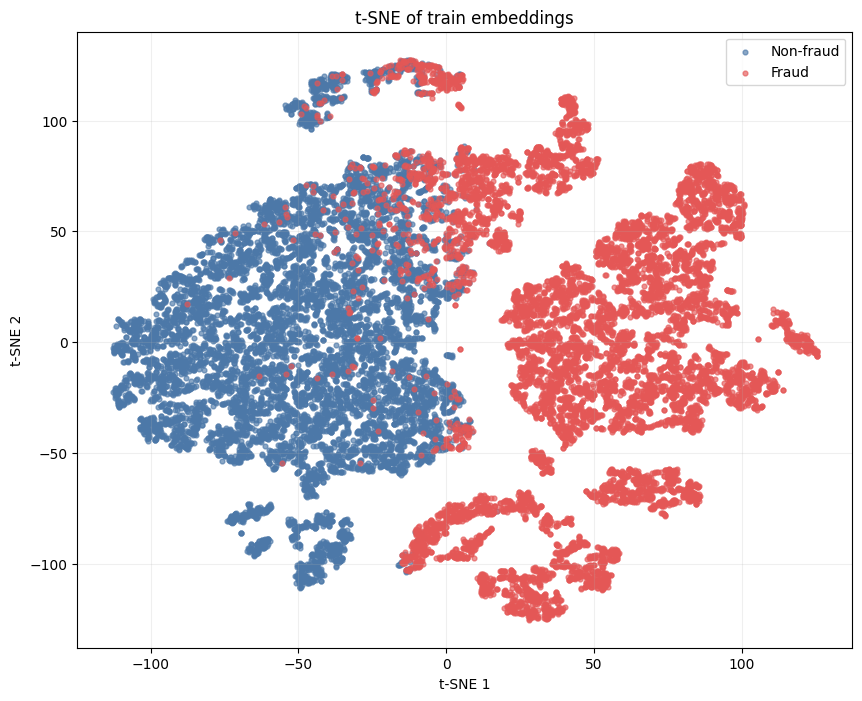

In [38]:
tsne_train_df = plot_tsne_embeddings(
    X_train,
    y_train,
    max_per_class=10000,
    title="t-SNE of train embeddings"
)

Using 9965 points for t-SNE
Non-fraud: 5000, Fraud: 4965


/opt/software/python/envs/google_colab_gpu_2025/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


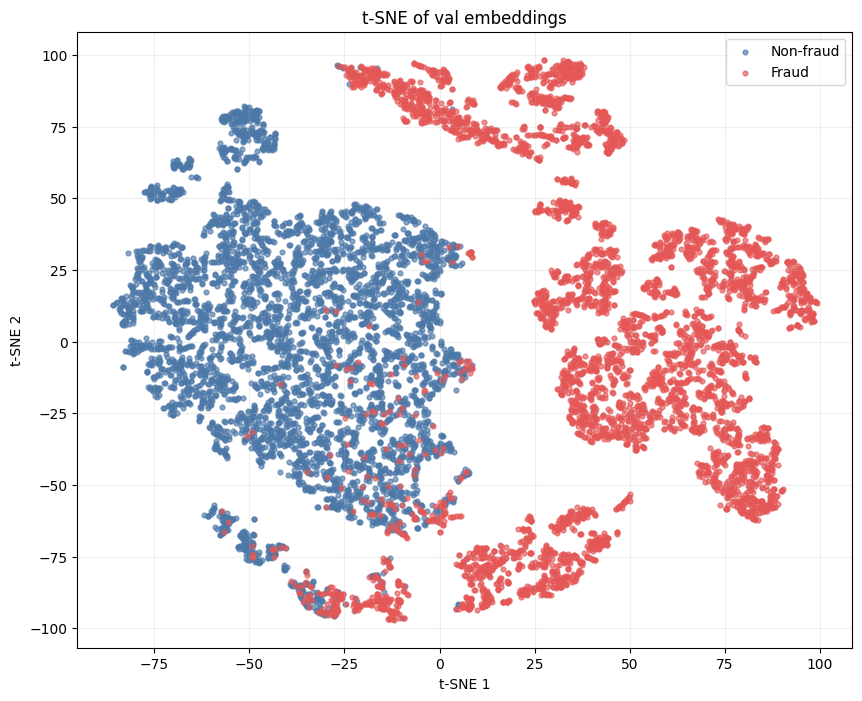

In [39]:
tsne_val_df = plot_tsne_embeddings(
    X_val,
    y_val,
    max_per_class=5000,
    title="t-SNE of val embeddings"
)

In [ ]:
tsne_test_df = plot_tsne_embeddings(
    X_test,
    y_test,
    max_per_class=5000,
    title="t-SNE of test embeddings"
)

Using 9102 points for t-SNE
Non-fraud: 5000, Fraud: 4102


/opt/software/python/envs/google_colab_gpu_2025/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [48]:
from catboost import CatBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# =========================
# CatBoost
# =========================
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=150
)
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)



0:	learn: 0.8640674	test: 0.8730089	best: 0.8730089 (0)	total: 1.55s	remaining: 25m 48s
100:	learn: 0.8731148	test: 0.8768964	best: 0.8769914 (84)	total: 2m 14s	remaining: 20m
200:	learn: 0.8800983	test: 0.8807260	best: 0.8809164 (198)	total: 4m 30s	remaining: 17m 53s
300:	learn: 0.8840356	test: 0.8817111	best: 0.8819970 (287)	total: 6m 48s	remaining: 15m 47s
400:	learn: 0.8869574	test: 0.8818575	best: 0.8824800 (338)	total: 9m 4s	remaining: 13m 33s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.8824800173
bestIteration = 338

Shrink model to first 339 iterations.


CatBoostClassifier(depth=6, early_stopping_rounds=150, eval_metric='F1', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [49]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    }

results = []
val_probs = cat_model.predict_proba(X_val)[:, 1]
val_preds = cat_model.predict(X_val)
val_metrics = compute_metrics(y_val, val_preds, val_probs)
test_probs = cat_model.predict_proba(X_test)[:, 1]
test_preds = cat_model.predict(X_test)
test_metrics = compute_metrics(y_test, test_preds, test_probs)

results.append({
    'model': 'CatBoost',
    'val_precision': val_metrics['precision'],
    'val_recall': val_metrics['recall'],
    'val_f1': val_metrics['f1'],
    'val_auc': val_metrics['auc'],
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_f1': test_metrics['f1'],
    'test_auc': test_metrics['auc'],
})
results_df = pd.DataFrame(results)
results_df

,model,val_precision,val_recall,val_f1,val_auc,test_precision,test_recall,test_f1,test_auc
0,CatBoost,0.951549,0.822759,0.88248,0.996999,0.983657,0.777669,0.868618,0.999415


In [51]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd


def compute_metrics_with_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold': threshold,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    }


def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    best_metrics = None
    best_f1 = -1.0

    for thr in tqdm(thresholds):
        metrics = compute_metrics_with_threshold(y_true, y_prob, threshold=thr)
        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_metrics = metrics

    return best_metrics


# =========================
# Logistic Regression
# =========================
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    )
)

logreg.fit(X_train, y_train)

# Вероятности на validation
val_probs = logreg.predict_proba(X_val)[:, 1]

# Подбираем лучший threshold по val F1
best_val_metrics = find_best_threshold(y_val, val_probs)
best_threshold = best_val_metrics['threshold']

print("Best threshold on validation:", round(best_threshold, 4))
print("Validation metrics at best threshold:")
print(best_val_metrics)

# Метрики на test с тем же threshold
test_probs = logreg.predict_proba(X_test)[:, 1]
test_metrics = compute_metrics_with_threshold(y_test, test_probs, threshold=best_threshold)

print("\nTest metrics with validation-selected threshold:")
print(test_metrics)

# В таблицу
logreg_results = pd.DataFrame([{
    'model': 'Logistic Regression',
    'best_threshold': best_threshold,
    'val_precision': best_val_metrics['precision'],
    'val_recall': best_val_metrics['recall'],
    'val_f1': best_val_metrics['f1'],
    'val_auc': best_val_metrics['auc'],
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_f1': test_metrics['f1'],
    'test_auc': test_metrics['auc'],
}])

logreg_results.round(4)

100%|██████████| 91/91 [17:21<00:00, 11.45s/it]


Best threshold on validation: 0.95
Validation metrics at best threshold:
{'threshold': 0.9500000000000002, 'precision': 0.48651221834338304, 'recall': 0.9262839879154079, 'f1': 0.6379525593008739, 'auc': 0.9966584551966522}

Test metrics with validation-selected threshold:
{'threshold': 0.9500000000000002, 'precision': 0.5864396830055768, 'recall': 0.9741589468551926, 'f1': 0.7321363136680102, 'auc': 0.999812536028752}


,model,best_threshold,val_precision,val_recall,val_f1,val_auc,test_precision,test_recall,test_f1,test_auc
0,Logistic Regression,0.95,0.4865,0.9263,0.638,0.9967,0.5864,0.9742,0.7321,0.9998


# Эксперимент без числовой ветки (дискретизация)


In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertConfig, BertModel
from collections import Counter
import json
import os
from tqdm import tqdm
import random
import pickle

class TabBertVocabBuilder:
    """Класс для создания словаря признаков транзакций и границ бинов"""

    def __init__(self, df, categorical_columns, numerical_columns, n_bins=10, special_tokens=None):
        """
        Args:
            df: DataFrame с транзакциями
            categorical_columns: список категориальных колонок
            numerical_columns: список числовых колонок
            n_bins: количество бинов для числовых признаков
            special_tokens: специальные токены
        """
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns
        self.n_bins = n_bins

        if special_tokens is None:
            self.special_tokens = ['[PAD]', '[CLS]', '[SEP]', '[MASK]', '[UNK]']
        else:
            self.special_tokens = special_tokens

        # Сохраняем границы бинов для каждой числовой колонки
        self.bin_edges = {}

        self.vocab = self._build_vocab(df)

    def _build_vocab(self, df):
        """Создание словаря из уникальных значений и границ бинов"""
        vocab_dict = {}

        # Добавляем специальные токены
        for i, token in enumerate(self.special_tokens):
            vocab_dict[token] = i

        current_idx = len(self.special_tokens)

        # Добавляем токены для категориальных колонок
        for col in self.categorical_columns:
            unique_values = df[col].astype(str).unique()
            for val in unique_values:
                token = f"{col}_{val}"
                if token not in vocab_dict:
                    vocab_dict[token] = current_idx
                    current_idx += 1

        # Создаем бины для числовых колонок
        for col in self.numerical_columns:
            values = df[col].dropna()

            if len(values) > 0:
                # Создаем бины с помощью квантилей
                percentiles = np.linspace(0, 100, self.n_bins + 1)
                bin_edges = np.percentile(values, percentiles)
                bin_edges = np.unique(bin_edges)  # Убираем дубликаты

                # Сохраняем границы бинов
                self.bin_edges[col] = bin_edges

                # Добавляем токены для каждого бина
                for i in range(len(bin_edges) - 1):
                    token = f"{col}_bin_{i}"
                    if token not in vocab_dict:
                        vocab_dict[token] = current_idx
                        current_idx += 1

                # Добавляем специальный токен для пропущенных значений
                token = f"{col}_missing"
                if token not in vocab_dict:
                    vocab_dict[token] = current_idx
                    current_idx += 1
            else:
                # Если нет значений, создаем хотя бы один бин
                self.bin_edges[col] = np.array([0, 1])
                token = f"{col}_bin_0"
                if token not in vocab_dict:
                    vocab_dict[token] = current_idx
                    current_idx += 1

        return vocab_dict

    def get_bin_index(self, col, value):
        """Получить индекс бина для числового значения"""
        if pd.isna(value):
            return len(self.bin_edges[col]) - 1  # Индекс для missing

        bin_edges = self.bin_edges[col]
        for i in range(len(bin_edges) - 1):
            if value <= bin_edges[i + 1]:
                return i
        return len(bin_edges) - 2  # Последний бин

    def save(self, path):
        """Сохранить словарь и границы бинов"""
        save_dict = {
            'vocab': self.vocab,
            'bin_edges': self.bin_edges,
            'categorical_columns': self.categorical_columns,
            'numerical_columns': self.numerical_columns,
            'special_tokens': self.special_tokens,
            'n_bins': self.n_bins
        }

        with open(path, 'wb') as f:
            pickle.dump(save_dict, f)
        print(f"TabBertVocab saved to {path}")

    @classmethod
    def load(cls, path):
        """Загрузить словарь и границы бинов"""
        with open(path, 'rb') as f:
            save_dict = pickle.load(f)

        # Создаем экземпляр без вычислений
        instance = cls.__new__(cls)
        instance.vocab = save_dict['vocab']
        instance.bin_edges = save_dict['bin_edges']
        instance.categorical_columns = save_dict['categorical_columns']
        instance.numerical_columns = save_dict['numerical_columns']
        instance.special_tokens = save_dict['special_tokens']
        instance.n_bins = save_dict['n_bins']

        print(f"TabBertVocab loaded from {path}. Size: {len(instance.vocab)}")
        return instance




In [2]:

class TabBertTokenizer:
    """Токенизатор для табличных данных с поддержкой бинов"""

    def __init__(self, vocab_builder, max_length=128):
        """
        Args:
            vocab_builder: экземпляр TabBertVocabBuilder с сохраненными бинами
            max_length: максимальная длина последовательности
        """
        self.vocab_builder = vocab_builder
        self.vocab = vocab_builder.vocab
        self.max_length = max_length
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def tokenize_transaction(self, transaction_row, categorical_columns=None, numerical_columns=None):
        """
        Токенизация одной транзакции с использованием бинов для числовых значений

        Args:
            transaction_row: строка DataFrame с транзакцией
            categorical_columns: список категориальных колонок (если None, используются из vocab_builder)
            numerical_columns: список числовых колонок (если None, используются из vocab_builder)

        Returns:
            список токенов
        """
        if categorical_columns is None:
            categorical_columns = self.vocab_builder.categorical_columns
        if numerical_columns is None:
            numerical_columns = self.vocab_builder.numerical_columns

        tokens = ['[CLS]']  # Начинаем с CLS токена

        # Добавляем категориальные признаки
        for col in categorical_columns:
            if col in transaction_row.index:
                val = str(transaction_row[col]) if not pd.isna(transaction_row[col]) else 'missing'
                token = f"{col}_{val}"
                if token not in self.vocab:
                    token = '[UNK]'
                tokens.append(token)
            else:
                tokens.append('[UNK]')

        # Добавляем числовые признаки с использованием бинов
        for col in numerical_columns:
            if col in transaction_row.index:
                if pd.isna(transaction_row[col]):
                    token = f"{col}_missing"
                else:
                    # Находим подходящий бин для числового значения
                    bin_idx = self.vocab_builder.get_bin_index(col, transaction_row[col])
                    token = f"{col}_bin_{bin_idx}"
            else:
                token = f"{col}_missing"

            if token not in self.vocab:
                token = '[UNK]'
            tokens.append(token)

        tokens.append('[SEP]')
        return tokens

    def convert_tokens_to_ids(self, tokens):
        """Конвертация токенов в индексы"""
        return [self.vocab.get(token, self.vocab['[UNK]']) for token in tokens]

    def convert_ids_to_tokens(self, ids):
        """Конвертация индексов в токены"""
        return [self.inv_vocab.get(i, '[UNK]') for i in ids]

    def decode_transaction(self, token_ids):
        """Декодирование транзакции обратно в читаемый вид"""
        tokens = self.convert_ids_to_tokens(token_ids)
        # Убираем специальные токены
        tokens = [t for t in tokens if t not in ['[CLS]', '[SEP]', '[PAD]']]
        return tokens




In [ ]:
df = pd.read_csv('card_transaction.v1.csv')

In [4]:
# Разделяем время на часы и минуты
df['hour'] = df['Time'].str.split(':').str[0].astype(int)
df['minute'] = df['Time'].str.split(':').str[1].astype(int)

df['timestamp'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'hour', 'minute']])
df['is_refund'] = df['Amount'].apply(lambda x: 1 if float(x[1:])>0 else 0)
    
df['Amount'] = df['Amount'].apply(lambda x: float(x[1:]) if float(x[1:])>0 else 1)

df['timestamp'] = df['timestamp'].values.astype('int64')

In [5]:
df.rename(columns = {'User' : 'user_id', 'Is Fraud?' : 'is_fraud'}, inplace=True)

df['is_fraud'] = df.is_fraud.apply(lambda x: 1 if x == 'Yes' else 0)

df['Errors?'] = df['Errors?'].fillna('None')




In [ ]:
categorical_columns = ['user_id', 'Card',  'Month' , 'Day', 'hour', 'minute',  'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'is_refund']
numerical_columns = ['Amount']

vocab_builder = TabBertVocabBuilder.load('tabbert_v5/tabbert_vocab_all.pkl')


tokenizer = TabBertTokenizer(vocab_builder, max_length=32)

TabBertVocab loaded from tabbert_v5/tabbert_vocab_all.pkl. Size: 145508


In [7]:
class TabBertFraudDataset(Dataset):
    def __init__(self, df, tokenizer, categorical_columns, numerical_columns,
                 transaction_col='transaction_id', user_col='user_id',
                 time_col='timestamp', label_col='is_fraud',
                 max_seq_length=128, history_size=10):
        """
        Датасет для обучения на фрод-детекшн
        
        Args:
            df: DataFrame со всеми транзакциями
            history_size: количество предыдущих транзакций для контекста
        """
        # Важно: сортируем по времени глобально, но сохраняем группы пользователей
        self.df = df.sort_values([user_col, time_col]).reset_index(drop=True)
        self.tokenizer = tokenizer
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns
        self.transaction_col = transaction_col
        self.user_col = user_col
        self.time_col = time_col
        self.label_col = label_col
        self.max_seq_length = max_seq_length
        self.history_size = history_size
        
        # Создаем индекс для быстрого доступа к истории по пользователю
        self.user_history = {}
        for user_id, group in self.df.groupby(user_col):
            # Сохраняем индексы транзакций в хронологическом порядке
            self.user_history[user_id] = group.index.tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        current_row = self.df.iloc[idx]
        user_id = current_row[self.user_col]
        
        # Находим позицию текущей транзакции в истории пользователя
        user_indices = self.user_history[user_id]
        
        # Важно: находим индекс, но не используем его для доступа к "будущим" транзакциям
        try:
            current_pos = user_indices.index(idx)
        except ValueError:
            # Если индекс не найден (маловероятно), возвращаем пустую историю
            history_indices = []
        else:
            # Берем только предыдущие транзакции (до current_pos)
            start_pos = max(0, current_pos - self.history_size)
            history_indices = user_indices[start_pos:current_pos]
        
        # Токенизируем текущую транзакцию
        current_ids, current_mask = self._tokenize_transaction(current_row)
        
        # Токенизируем исторические транзакции
        history_ids = []
        history_mask = []
        
        for hist_idx in history_indices:
            hist_row = self.df.iloc[hist_idx]
            hist_ids, hist_mask = self._tokenize_transaction(hist_row)
            history_ids.append(hist_ids)
            history_mask.append(hist_mask)
        
        # Дополняем историю до history_size нулями
        pad_token_id = self.tokenizer.vocab.get('[PAD]', 0)
        while len(history_ids) < self.history_size:
            history_ids.append([pad_token_id] * self.max_seq_length)
            history_mask.append([0] * self.max_seq_length)
        
        # Инвертируем порядок истории (самая свежая последняя) - опционально
        # history_ids = history_ids[::-1]
        # history_mask = history_mask[::-1]
        
        return {
            'current_ids': torch.tensor(current_ids, dtype=torch.long),
            'current_mask': torch.tensor(current_mask, dtype=torch.long),
            'history_ids': torch.tensor(history_ids, dtype=torch.long),
            'history_mask': torch.tensor(history_mask, dtype=torch.long),
            'label': torch.tensor(current_row[self.label_col], dtype=torch.long)
        }
    
    def _tokenize_transaction(self, row):
        """Вспомогательный метод для токенизации одной транзакции"""
        tokens = self.tokenizer.tokenize_transaction(
            row, self.categorical_columns, self.numerical_columns
        )
        
        # Обрезаем до max_seq_length
        tokens = tokens[:self.max_seq_length]
        ids = self.tokenizer.convert_tokens_to_ids(tokens)
        mask = [1] * len(ids)
        
        # Паддинг
        pad_token_id = self.tokenizer.vocab.get('[PAD]', 0)
        pad_len = self.max_seq_length - len(ids)
        ids += [pad_token_id] * pad_len
        mask += [0] * pad_len
        
        return ids, mask

In [ ]:
class TabBertForFraudDetection(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_classes=2, max_history = 10,
                  freeze_first_bert=True, num_hidden_layers = 3):
        super().__init__()
        
        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=hidden_size,
            num_hidden_layers=num_hidden_layers,
            num_attention_heads=4,
            max_position_embeddings=196,
            type_vocab_size=2
        )

        self.transaction_bert = BertModel(config)
        
       
        # Второй BERT (анализирует последовательность)
        max_history = 10
        config = BertConfig(
            vocab_size=1,  # вход - эмбеддинги
            hidden_size=hidden_size,
            num_hidden_layers=2,  # меньше слоев = меньше переобучение
            num_attention_heads=4,
            intermediate_size=hidden_size * 2,
            max_position_embeddings=1024,
            hidden_dropout_prob=0.3,  # увеличенный dropout
            attention_probs_dropout_prob=0.3
        )
        
        self.history_bert = BertModel(config)
        
        # Классификатор с Dropout и BatchNorm
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            # nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size // 2, num_classes)
        )
        
        self.mlm_head = nn.Linear(hidden_size, vocab_size)
        
        # Веса для классов (очень важно!)
        self.register_buffer('class_weights', torch.tensor([1.0, 5.0]))

        
    def forward_mlm(self, current_ids, current_mask, history_ids, history_mask, 
                current_labels, history_labels):
        batch_size = current_ids.size(0)
        max_history = history_ids.size(1)

        sequence_output_list = []
        mask_list = []
        labels_list = []
        history_exists_mask = []

        # Обработка текущей транзакции
        current_outputs = self.transaction_bert(
            input_ids=current_ids,
            attention_mask=current_mask,
            output_hidden_states=True
        )
        # Берем ВСЕ токены, не только CLS
        current_seq = current_outputs.last_hidden_state  # [batch, seq_len, hidden]
        sequence_output_list.append(current_seq)
        mask_list.append(current_mask)
        labels_list.append(current_labels)

        # Обработка исторических транзакций
        for i in range(max_history):
            # Проверяем, реальная ли транзакция
            trans_exists = (history_mask[:, i, 0] == 1).float()
            history_exists_mask.append(trans_exists.unsqueeze(1))

            # Кодируем транзакцию
            hist_outputs = self.transaction_bert(
                input_ids=history_ids[:, i, :],
                attention_mask=history_mask[:, i, :],
                output_hidden_states=True
            )
            hist_seq = hist_outputs.last_hidden_state  # [batch, seq_len, hidden]
            sequence_output_list.append(hist_seq)
            mask_list.append(history_mask[:, i, :])
            labels_list.append(history_labels[:, i, :])

        # Объединяем все
        sequence_output = torch.cat(sequence_output_list, dim=1)  # [batch, total_seq, hidden]
        all_masks = torch.cat(mask_list, dim=1)  # [batch, total_seq]
        all_labels = torch.cat(labels_list, dim=1)  # [batch, total_seq]

        # Маска для второго BERT (по транзакциям, не по токенам)
        history_exists = torch.cat(history_exists_mask, dim=1)  # [batch, max_history]
        # Добавляем текущую транзакцию (всегда 1)
        attention_mask_transactions = torch.cat([
            history_exists, 
            torch.ones(batch_size, 1).to(history_exists.device)
        ], dim=1)  # [batch, max_history+1]

        # Пропускаем через history_bert
        outputs = self.history_bert(
            inputs_embeds=sequence_output,
            attention_mask=all_masks  # внимание на уровне токенов!
        )

        # MLM предсказание (на всех токенах)
        prediction_scores = self.mlm_head(outputs.last_hidden_state)

        # Расчет loss
        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        active_loss = (all_masks == 1).view(-1)
        active_logits = prediction_scores.view(-1, prediction_scores.size(-1))[active_loss]
        active_labels = all_labels.view(-1)[active_loss]
        loss = loss_fct(active_logits, active_labels)

        return loss, prediction_scores
    


    def forward(self, input_ids, attention_mask, labels=None):
            """
            Прямой проход для предсказания на всех позициях последовательности
            Args:
                input_ids: [batch_size, seq_len, max_seq_length] - последовательность транзакций
                attention_mask: [batch_size, seq_len, max_seq_length] - маски для каждой транзакции
                labels: [batch_size, seq_len] - лейблы для каждой транзакции (опционально)
            """
            batch_size, seq_len = input_ids.shape[:2]

            # Получаем CLS эмбеддинги для всех транзакций в последовательности
            transaction_embeds = []
            valid_mask = []

            for i in range(seq_len):
                # Пропускаем каждую транзакцию через первый BERT
                trans_outputs = self.transaction_bert(
                    input_ids[:, i, :], 
                    attention_mask[:, i, :]
                )
                # Берем CLS токен
                trans_cls = trans_outputs.last_hidden_state[:, 0, :]  # [batch, hidden]
                transaction_embeds.append(trans_cls.unsqueeze(1))

                # Проверяем, реальная ли транзакция (по первому токену маски)
                is_valid = (attention_mask[:, i, 0] == 1).float()  # [batch]
                valid_mask.append(is_valid.unsqueeze(1))

            # Объединяем все эмбеддинги
            transaction_embeds = torch.cat(transaction_embeds, dim=1)  # [batch, seq_len, hidden]
            valid_mask = torch.cat(valid_mask, dim=1)  # [batch, seq_len]

            # Пропускаем через history_bert
            outputs = self.history_bert(
                inputs_embeds=transaction_embeds,
                attention_mask=valid_mask
            )

            # Получаем эмбеддинги для каждой позиции
            sequence_output = outputs.last_hidden_state  # [batch, seq_len, hidden]
            
#            reshape
            batch_size, seq_len, hidden_size = sequence_output.shape
            sequence_output_reshaped = sequence_output.reshape(-1, hidden_size)  # [batch*seq_len, hidden]

            # Применяем классификатор
            logits_reshaped = self.classifier(sequence_output_reshaped)  # [batch*seq_len, num_classes]

            # Возвращаем обратную форму
            logits = logits_reshaped.reshape(batch_size, seq_len, -1)  # [batch, seq_len, num_classes]


            # Классификация для каждой позиции
            # logits = self.classifier(sequence_output)  # [batch, seq_len, num_classes]

            loss = None
            if labels is not None:
                loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
                # Учитываем только реальные транзакции (где labels != -100)
                active_loss = (labels != -100).view(-1)
                active_logits = logits.view(-1, logits.size(-1))[active_loss]
                active_labels = labels.view(-1)[active_loss]
                loss = loss_fn(active_logits, active_labels)

            return loss, logits

    

In [9]:
class TabBertFraudDataset(Dataset):
    def __init__(self, df, tokenizer, categorical_columns, numerical_columns,
                 transaction_col='transaction_id', user_col='user_id',
                 time_col='timestamp', label_col='is_fraud',
                 max_seq_length=128, window_size=10, stride=None, min_window_size=2):
        """
        Датасет для обучения на фрод-детекшн с поддержкой stride
        """
        # Сортируем по времени для каждого пользователя
        self.df = df.sort_values([user_col, time_col]).reset_index(drop=True)
        self.tokenizer = tokenizer
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns
        self.transaction_col = transaction_col
        self.user_col = user_col
        self.time_col = time_col
        self.label_col = label_col
        self.max_seq_length = max_seq_length
        self.window_size = window_size
        self.stride = stride if stride is not None else window_size
        self.min_window_size = min_window_size
        
        # Создаем окна для каждого пользователя
        self.windows = []
        self._create_windows()
    
    def _create_windows(self):
        """Создает окна фиксированного размера для каждого пользователя"""
        for user_id, group in self.df.groupby(self.user_col):
            indices = group.index.tolist()
            
            # Создаем окна с заданным шагом
            for start_idx in range(0, len(indices), self.stride):
                end_idx = min(start_idx + self.window_size, len(indices))
                window_indices = indices[start_idx:end_idx]
                
                # ПРОВЕРКА: окно должно быть не меньше минимального размера
                if len(window_indices) >= self.min_window_size:
                    # Сохраняем ИНДЕКСЫ и РЕАЛЬНЫЙ РАЗМЕР окна
                    self.windows.append({
                        'indices': window_indices,
                        'actual_size': len(window_indices)
                    })
    
    def _tokenize_transaction(self, row):
        """
        Токенизация одной транзакции
        Предполагается, что у tokenizer есть метод tokenize_transaction
        """
        tokens = self.tokenizer.tokenize_transaction(
            row, self.categorical_columns, self.numerical_columns
        )
        
        # Обрезаем до max_seq_length
        tokens = tokens[:self.max_seq_length]
        ids = self.tokenizer.convert_tokens_to_ids(tokens)
        mask = [1] * len(ids)
        
        # Паддинг
        pad_token_id = self.tokenizer.vocab.get('[PAD]', 0)
        pad_len = self.max_seq_length - len(ids)
        ids += [pad_token_id] * pad_len
        mask += [0] * pad_len
        
        return ids, mask
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        window = self.windows[idx]
        window_indices = window['indices']
        actual_size = window['actual_size']
        
        # Токенизируем ВСЕ транзакции в окне
        all_ids = []
        all_masks = []
        all_labels = []
        
        for hist_idx in window_indices:
            row = self.df.iloc[hist_idx]
            ids, mask = self._tokenize_transaction(row)
            all_ids.append(ids)
            all_masks.append(mask)
            all_labels.append(row[self.label_col])
        
        # ВАЖНО: Паддинг до window_size, чтобы все окна были одинакового размера
        pad_token_id = self.tokenizer.vocab.get('[PAD]', 0)
        while len(all_ids) < self.window_size:
            all_ids.append([pad_token_id] * self.max_seq_length)
            all_masks.append([0] * self.max_seq_length)
            all_labels.append(-100)  # ignore index для loss
        
        return {
            'input_ids': torch.tensor(all_ids, dtype=torch.long),  # [window_size, seq_len]
            'attention_mask': torch.tensor(all_masks, dtype=torch.long),  # [window_size, seq_len]
            'labels': torch.tensor(all_labels, dtype=torch.long),  # [window_size]
            'actual_size': actual_size  # полезно для статистики
        }

In [ ]:
mlm_model = TabBertForFraudDetection(len(vocab_builder.vocab), hidden_size=128)

save_path = 'tabbert_v5/model_base_4.pth'
loaded_state_dict = torch.load(save_path)

mlm_model.load_state_dict(loaded_state_dict)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


mlm_model = mlm_model.to(device)  # Явный перенос на CUDA




<ipython-input-10-cec916443f5f>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_state_dict = torch.load(save_path)


Using device: cuda


In [26]:
import pandas as pd

def split_by_time_per_user(
    df,
    user_col="user",
    time_col="timestamp",
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    df = df.sort_values([user_col, time_col]).reset_index(drop=True)

    train_parts = []
    val_parts = []
    test_parts = []

    for _, group in df.groupby(user_col, sort=False):
        n = len(group)

        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        # чтобы не развалиться на маленьких группах
        if train_end == 0:
            train_end = min(1, n)
        if val_end <= train_end and n - train_end > 1:
            val_end = train_end + 1

        train_parts.append(group.iloc[:train_end])
        val_parts.append(group.iloc[train_end:val_end])
        test_parts.append(group.iloc[val_end:])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, val_df, test_df

In [ ]:
train_df, val_df, test_df = split_by_time_per_user(
    df,
    user_col="user_id",
    time_col="timestamp",
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
)

print(len(train_df), len(val_df), len(test_df))
print(len(train_df) / len(df), len(val_df) / len(df), len(test_df) / len(df))



In [ ]:
train_dataset = TabBertFraudDataset(
    train_df, tokenizer, categorical_columns, numerical_columns, max_seq_length=18
)

val_dataset = TabBertFraudDataset(
    val_df, tokenizer, categorical_columns, numerical_columns, max_seq_length=18
)

test_dataset = TabBertFraudDataset(
    test_df, tokenizer, categorical_columns, numerical_columns, max_seq_length=18
)

In [ ]:
import os

from torch.utils.data import random_split
AVAILABLE_CPU = os.cpu_count() or 2
NUM_WORKERS = min(8, max(2, AVAILABLE_CPU - 2))
BATCH_SIZE = 256
PIN_MEMORY = device.type == 'cuda'

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
    'persistent_workers': NUM_WORKERS > 0,
    'drop_last': False
}

if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 4

fraud_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs
)

fraud_val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

fraud_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

print(f"\nCPU cores available: {AVAILABLE_CPU}")
print(f"Using DataLoader workers: {NUM_WORKERS}")



CPU cores available: 44
Using DataLoader workers: 8


In [89]:
# del fraud_train_loader
# del fraud_val_loader
# del fraud_test_loader

In [20]:
import os
import torch
from copy import deepcopy
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

def train_tabbert(
    model,
    train_loader,
    val_loader,
    epochs=20,
    device='cuda',
    save_dir='tabbert_checkpoints',
    save_prefix='tabbert_model_v2'
):
    """Обучение с ранней остановкой, scheduler и сохранением модели."""
    
    model = model.to(device)
    os.makedirs(save_dir, exist_ok=True)

    optimizer = torch.optim.AdamW([
        {'params': model.history_bert.parameters(), 'lr': 2e-5},
        {'params': model.classifier.parameters(), 'lr': 2e-5},
        {'params': model.transaction_bert.parameters(), 'lr': 1e-5}
    ], weight_decay=0.1)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, verbose=True
    )
    
    best_val_f1 = 0
    patience = 5
    patience_counter = 0
    best_model_state = None
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc': [], 'val_auc': []
    }
    
    for epoch in range(epochs):
        print(f"\n{'='*50}")
        print(f"Эпоха {epoch+1}/{epochs}")
        print('='*50)
        
        model.train()
        train_loss = 0
        train_preds = []
        train_probs = []
        train_labels = []
        
        for batch in tqdm(train_loader, desc="Training"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            loss, logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item()
            valid_mask = (labels != -100)
            
            probs = F.softmax(logits, dim=-1)
            preds = logits.argmax(dim=-1)
            
            valid_preds = preds[valid_mask].detach().cpu().numpy()
            valid_probs = probs[valid_mask][:, 1].detach().cpu().numpy()
            valid_labels = labels[valid_mask].detach().cpu().numpy()
            
            train_preds.extend(valid_preds)
            train_probs.extend(valid_probs)
            train_labels.extend(valid_labels)
        
        train_loss = train_loss / len(train_loader)
        train_precision = precision_score(train_labels, train_preds, zero_division=0)
        train_recall = recall_score(train_labels, train_preds, zero_division=0)
        train_f1 = f1_score(train_labels, train_preds, zero_division=0)
        train_auc = roc_auc_score(train_labels, train_probs)
        
        model.eval()
        val_loss = 0
        val_preds = []
        val_probs = []
        val_labels = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validation"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                loss, logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                
                val_loss += loss.item()
                
                probs = F.softmax(logits, dim=-1)
                preds = logits.argmax(dim=-1)
                valid_mask = (labels != -100)

                valid_preds = preds[valid_mask].detach().cpu().numpy()
                valid_probs = probs[:, :, 1][valid_mask].detach().cpu().numpy()
                valid_labels = labels[valid_mask].detach().cpu().numpy()

                val_preds.extend(valid_preds)
                val_probs.extend(valid_probs)
                val_labels.extend(valid_labels)

        val_loss = val_loss / len(val_loader)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        val_auc = roc_auc_score(val_labels, val_probs)
        
        scheduler.step(val_f1)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_precision'].append(train_precision)
        history['val_precision'].append(val_precision)
        history['train_recall'].append(train_recall)
        history['val_recall'].append(val_recall)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)
        
        print(f"\n📊 РЕЗУЛЬТАТЫ ЭПОХИ {epoch+1}:")
        print(f"  Train - Loss: {train_loss:.4f}")
        print(f"          Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
        print(f"          AUC: {train_auc:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}")
        print(f"          Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
        print(f"          AUC: {val_auc:.4f}")
        
        val_probs_array = np.array(val_probs)
        val_labels_array = np.array(val_labels)
        print(f"\n📈 Статистика вероятностей (val):")
        print(f"  Всего: min={val_probs_array.min():.4f}, max={val_probs_array.max():.4f}, mean={val_probs_array.mean():.4f}")
        
        fraud_mask = val_labels_array == 1
        if fraud_mask.sum() > 0:
            print(f"  Фрод (класс 1): mean={val_probs_array[fraud_mask].mean():.4f}, max={val_probs_array[fraud_mask].max():.4f}")
        
        non_fraud_mask = val_labels_array == 0
        if non_fraud_mask.sum() > 0:
            print(f"  Не-фрод (класс 0): mean={val_probs_array[non_fraud_mask].mean():.4f}, max={val_probs_array[non_fraud_mask].max():.4f}")
        print("-" * 50)

        checkpoint_path = os.path.join(save_dir, f"{save_prefix}_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1': best_val_f1,
            'history': history,
            'train_metrics': {
                'loss': train_loss,
                'precision': train_precision,
                'recall': train_recall,
                'f1': train_f1,
                'auc': train_auc,
            },
            'val_metrics': {
                'loss': val_loss,
                'precision': val_precision,
                'recall': val_recall,
                'f1': val_f1,
                'auc': val_auc,
            }
        }, checkpoint_path)
        print(f"💾 Сохранен checkpoint: {checkpoint_path}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
            print(f"✅ НОВЫЙ ЛУЧШИЙ F1: {best_val_f1:.4f}")

            best_model_path = os.path.join(save_dir, f"{save_prefix}_best.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': best_model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_f1': best_val_f1,
                'history': history,
                'val_metrics': {
                    'loss': val_loss,
                    'precision': val_precision,
                    'recall': val_recall,
                    'f1': val_f1,
                    'auc': val_auc,
                }
            }, best_model_path)
            print(f"🏆 Сохранена лучшая модель: {best_model_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"🛑 Ранняя остановка на эпохе {epoch+1}")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n🏆 Загружена лучшая модель с F1 = {best_val_f1:.4f}")
    
    return model, history

In [21]:
import torch.nn.functional as F

In [ ]:
new_model, history = train_tabbert(
    mlm_model,
    fraud_train_loader,
    fraud_val_loader,
    epochs=16,)


Эпоха 1/16


Validation: 100%|██████████| 1432/1432 [02:09<00:00, 11.06it/s]



📊 РЕЗУЛЬТАТЫ ЭПОХИ 1:
  Train - Loss: 0.0377
          Precision: 0.0005, Recall: 0.0001, F1: 0.0002
          AUC: 0.9096
  Val   - Loss: 0.0095
          Precision: 0.0000, Recall: 0.0000, F1: 0.0000
          AUC: 0.9941

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.4815, mean=0.0013
  Фрод (класс 1): mean=0.4279, max=0.4815
  Не-фрод (класс 0): mean=0.0008, max=0.4815
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_checkpoints/tabbert_model_v2_epoch_1.pth

Эпоха 2/16


Validation: 100%|██████████| 1432/1432 [02:06<00:00, 11.34it/s]



📊 РЕЗУЛЬТАТЫ ЭПОХИ 2:
  Train - Loss: 0.0086
          Precision: 0.7719, Recall: 0.6855, F1: 0.7261
          AUC: 0.9884
  Val   - Loss: 0.0083
          Precision: 0.8107, Recall: 0.8546, F1: 0.8320
          AUC: 0.9963

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.6318, mean=0.0011
  Фрод (класс 1): mean=0.5494, max=0.6318
  Не-фрод (класс 0): mean=0.0003, max=0.6318
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_checkpoints/tabbert_model_v2_epoch_2.pth
✅ НОВЫЙ ЛУЧШИЙ F1: 0.8320
🏆 Сохранена лучшая модель: tabbert_checkpoints/tabbert_model_v2_best.pth

Эпоха 3/16


Training:  22%|██▏       | 1471/6671 [03:26<11:53,  7.29it/s]

In [48]:
import numpy as np
import torch
from tqdm import tqdm


def extract_transaction_embeddings(model, loader, device='cuda'):
    """
    Извлекает context-aware эмбеддинги транзакций и соответствующие labels
    из DataLoader'а второго эксперимента TabBertFraudDataset.

    Ожидается batch со структурой:
        input_ids: [batch_size, window_size, max_seq_length]
        attention_mask: [batch_size, window_size, max_seq_length]
        labels: [batch_size, window_size]

    Возвращает:
        X: np.ndarray shape [n_transactions, hidden_size]
        y: np.ndarray shape [n_transactions]
    """
    model.eval()
    model = model.to(device)

    use_amp = str(device).startswith('cuda') and torch.cuda.is_available()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting embeddings"):
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            batch_size, seq_len = input_ids.shape[:2]

            with torch.autocast(
                device_type='cuda',
                dtype=torch.float16,
                enabled=use_amp
            ):
                transaction_embeds = []
                valid_mask = []

                for i in range(seq_len):
                    trans_outputs = model.transaction_bert(
                        input_ids=input_ids[:, i, :],
                        attention_mask=attention_mask[:, i, :]
                    )

                    trans_cls = trans_outputs.last_hidden_state[:, 0, :]
                    transaction_embeds.append(trans_cls.unsqueeze(1))

                    is_valid = (attention_mask[:, i, 0] == 1).float()
                    valid_mask.append(is_valid.unsqueeze(1))

                transaction_embeds = torch.cat(transaction_embeds, dim=1)
                valid_mask = torch.cat(valid_mask, dim=1)

                outputs = model.history_bert(
                    inputs_embeds=transaction_embeds,
                    attention_mask=valid_mask
                )

                sequence_output = outputs.last_hidden_state  # [batch, seq_len, hidden_size]

            valid_tx_mask = labels != -100

            batch_embeddings = sequence_output[valid_tx_mask].float().cpu()
            batch_labels = labels[valid_tx_mask].cpu()

            if batch_embeddings.numel() > 0:
                all_embeddings.append(batch_embeddings)
                all_labels.append(batch_labels)

    hidden_size = model.transaction_bert.config.hidden_size

    if not all_embeddings:
        return np.empty((0, hidden_size), dtype=np.float32), np.empty((0,), dtype=np.int64)

    X = torch.cat(all_embeddings, dim=0).numpy()
    y = torch.cat(all_labels, dim=0).numpy()

    return X, y

In [49]:
X_train, y_train = extract_transaction_embeddings(mlm_model, fraud_train_loader, device=device)
X_val, y_val = extract_transaction_embeddings(mlm_model, fraud_val_loader, device=device)
X_test, y_test = extract_transaction_embeddings(mlm_model, fraud_test_loader, device=device)

Extracting embeddings: 100%|██████████| 1433/1433 [02:12<00:00, 10.83it/s]


# Визуализацияэмбеддинговбезчисловойветки

Using 20000 points for t-SNE
Non-fraud: 10000, Fraud: 10000


/opt/software/python/envs/google_colab_gpu_2024/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


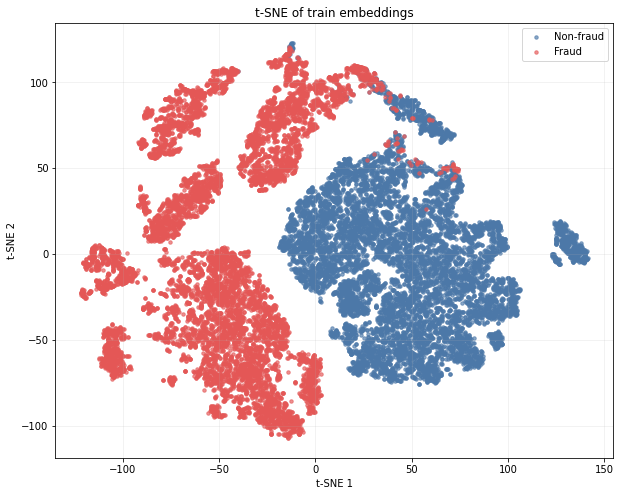

In [51]:
tsne_train_df = plot_tsne_embeddings(
    X_train,
    y_train,
    max_per_class=10000,
    title="t-SNE of train embeddings"
)

Using 9965 points for t-SNE
Non-fraud: 5000, Fraud: 4965


/opt/software/python/envs/google_colab_gpu_2024/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


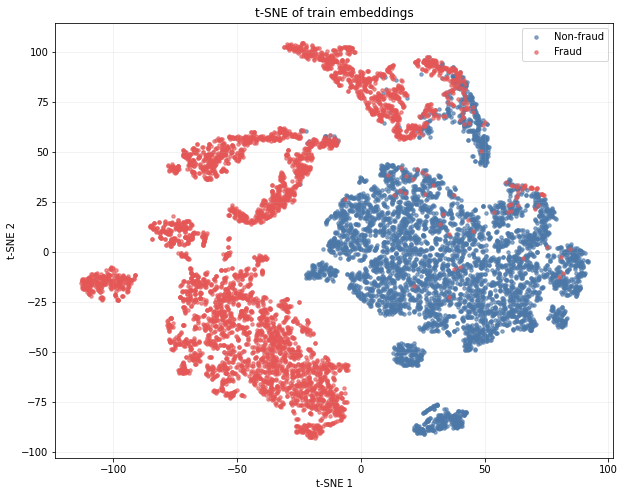

In [52]:
tsne_train_df = plot_tsne_embeddings(
    X_val,
    y_val,
    max_per_class=5000,
    title="t-SNE of train embeddings"
)

Using 9102 points for t-SNE
Non-fraud: 5000, Fraud: 4102


/opt/software/python/envs/google_colab_gpu_2024/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


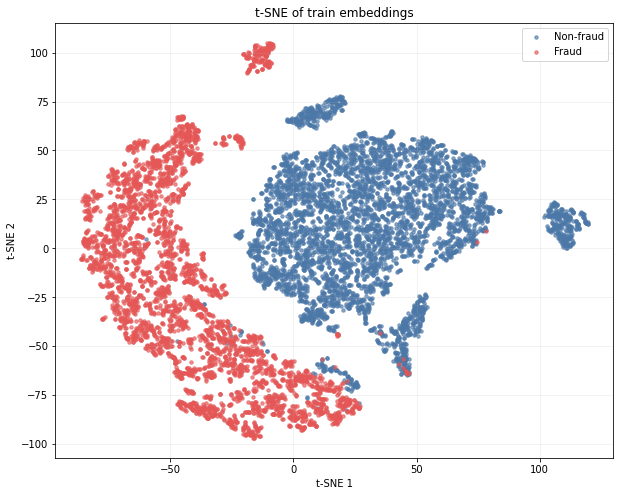

In [53]:
tsne_train_df = plot_tsne_embeddings(
    X_test,
    y_test,
    max_per_class=5000,
    title="t-SNE of train embeddings"
)

In [ ]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


def safe_binary_auc(y_true, y_score):
    unique_classes = np.unique(y_true)
    if unique_classes.shape[0] < 2:
        return float('nan')
    return roc_auc_score(y_true, y_score)


def collect_model_probs_second_experiment(model, loader, device='cuda'):
    """Собирает вероятности класса 1, labels и средний loss для второй нейронки во втором эксперименте."""
    model.eval()
    model = model.to(device)

    use_amp_local = str(device).startswith('cuda') and torch.cuda.is_available()

    all_probs = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(loader, desc='Collecting probs (2nd experiment)'):
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp_local):
                loss, logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=-1)[..., 1]
            valid_mask = (labels != -100)

            batch_probs = probs[valid_mask].detach().cpu().numpy()
            batch_labels = labels[valid_mask].detach().cpu().numpy()

            all_probs.extend(batch_probs.tolist())
            all_labels.extend(batch_labels.tolist())

    avg_loss = total_loss / len(loader)
    return np.array(all_probs), np.array(all_labels), avg_loss


def compute_metrics_at_threshold(y_true, y_prob, threshold=0.5, loss=None):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold': threshold,
        'loss': loss,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': safe_binary_auc(y_true, y_prob)
    }


def find_best_threshold(y_true, y_prob, loss=None, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    best_metrics = None
    best_f1 = -1.0

    for thr in tqdm(thresholds):
        metrics = compute_metrics_at_threshold(y_true, y_prob, threshold=thr, loss=loss)
        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_metrics = metrics

    return best_metrics


second_experiment_model = new_model if 'new_model' in globals() else mlm_model

val_probs, val_labels, val_loss = collect_model_probs_second_experiment(
    mlm_model,
    fraud_val_loader,
    device=device
)

best_val_metrics = find_best_threshold(val_labels, val_probs, loss=val_loss)
best_threshold = best_val_metrics['threshold']

print(f'Best threshold on validation (2nd experiment): {best_threshold:.2f}')
print('Validation metrics at best threshold:')
print(best_val_metrics)

test_probs, test_labels, test_loss = collect_model_probs_second_experiment(
    mlm_model,
    fraud_test_loader,
    device=device
)

test_metrics = compute_metrics_at_threshold(
    test_labels,
    test_probs,
    threshold=best_threshold,
    loss=test_loss
)

print('\nTest metrics with validation-selected threshold:')
print(test_metrics)

pd.DataFrame([{
    'model': 'TabBERT classifier (2nd experiment)',
    'best_threshold': best_threshold,
    'val_loss': best_val_metrics['loss'],
    'val_precision': best_val_metrics['precision'],
    'val_recall': best_val_metrics['recall'],
    'val_f1': best_val_metrics['f1'],
    'val_auc': best_val_metrics['auc'],
    'test_loss': test_metrics['loss'],
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_f1': test_metrics['f1'],
    'test_auc': test_metrics['auc'],
}]).round(4)


In [ ]:
val_probs, val_labels, val_loss = collect_model_probs_second_experiment(
    mlm_model,
    fraud_test_loader,
    device=device
)

best_val_metrics = find_best_threshold(val_labels, val_probs, loss=val_loss)
best_threshold = best_val_metrics['threshold']

print(f'Best threshold on validation (2nd experiment): {best_threshold:.2f}')
print('Validation metrics at best threshold:')
print(best_val_metrics)

In [56]:
# import sys
# !{sys.executable} -m pip install --user catboost

# # После установки, добавим путь в sys.path
# import site
# user_site = site.getusersitepackages()
# if user_site not in sys.path:
#     sys.path.insert(0, user_site)
#     print(f"Добавлен путь: {user_site}")

# # Теперь должно работать
# import catboost
# print(f"CatBoost version: {catboost.__version__}")

In [57]:
from catboost import CatBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# =========================
# CatBoost
# =========================
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=150
)
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)



0:	learn: 0.9050554	test: 0.8336729	best: 0.8336729 (0)	total: 1.6s	remaining: 26m 44s
100:	learn: 0.9206279	test: 0.8469898	best: 0.8472071 (89)	total: 1m 55s	remaining: 17m 6s
200:	learn: 0.9243942	test: 0.8475683	best: 0.8477599 (149)	total: 3m 55s	remaining: 15m 37s
300:	learn: 0.9280952	test: 0.8490134	best: 0.8494823 (291)	total: 5m 56s	remaining: 13m 47s
400:	learn: 0.9316767	test: 0.8494553	best: 0.8495151 (390)	total: 8m	remaining: 11m 57s
500:	learn: 0.9343084	test: 0.8494764	best: 0.8504469 (455)	total: 10m 2s	remaining: 10m
600:	learn: 0.9369316	test: 0.8492583	best: 0.8504469 (455)	total: 12m 1s	remaining: 7m 59s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.8504469152
bestIteration = 455

Shrink model to first 456 iterations.


CatBoostClassifier(depth=6, early_stopping_rounds=150, eval_metric='F1', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    }

results = []
val_probs = cat_model.predict_proba(X_val)[:, 1]
val_preds = cat_model.predict(X_val)
val_metrics = compute_metrics(y_val, val_preds, val_probs)
test_probs = cat_model.predict_proba(X_test)[:, 1]
test_preds = cat_model.predict(X_test)
test_metrics = compute_metrics(y_test, test_preds, test_probs)

results.append({
    'model': 'CatBoost',
    'val_precision': val_metrics['precision'],
    'val_recall': val_metrics['recall'],
    'val_f1': val_metrics['f1'],
    'val_auc': val_metrics['auc'],
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_f1': test_metrics['f1'],
    'test_auc': test_metrics['auc'],
})
results_df = pd.DataFrame(results)
results_df

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd


def compute_metrics_with_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold': threshold,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    }


def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.03)

    best_metrics = None
    best_f1 = -1.0

    for thr in tqdm(thresholds):
        metrics = compute_metrics_with_threshold(y_true, y_prob, threshold=thr)
        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_metrics = metrics

    return best_metrics


# =========================
# Logistic Regression
# =========================
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    )
)

logreg.fit(X_train, y_train)

# Вероятности на validation
val_probs = logreg.predict_proba(X_val)[:, 1]

# Подбираем лучший threshold по val F1
best_val_metrics = find_best_threshold(y_val, val_probs)
best_threshold = best_val_metrics['threshold']

print("Best threshold on validation:", round(best_threshold, 4))
print("Validation metrics at best threshold:")
print(best_val_metrics)

# Метрики на test с тем же threshold
test_probs = logreg.predict_proba(X_test)[:, 1]
test_metrics = compute_metrics_with_threshold(y_test, test_probs, threshold=best_threshold)

print("\nTest metrics with validation-selected threshold:")
print(test_metrics)

# В таблицу
logreg_results = pd.DataFrame([{
    'model': 'Logistic Regression',
    'best_threshold': best_threshold,
    'val_precision': best_val_metrics['precision'],
    'val_recall': best_val_metrics['recall'],
    'val_f1': best_val_metrics['f1'],
    'val_auc': best_val_metrics['auc'],
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_f1': test_metrics['f1'],
    'test_auc': test_metrics['auc'],
}])

logreg_results.round(4)